---

# Data Science Competition JOINTS x INSPIRE UGM 2026 (v14)

*Memprediksi penjualan tiket harian D4 sampai D10 per pasangan film dan klaster bioskop dari tiga hari pertama. Model dilatih juga pada salinan pasar sepi (binomial thinning) karena periode uji berperilaku seperti periode latih dengan pembeli lebih sedikit: keputusan bioskop dan dinamika film sama, jumlah penonton separuhnya.*

---

## [Nama Tim]

- [Nama Anggota 1] (Ketua)
- [Nama Anggota 2]
- [Nama Anggota 3]

---

## Table of Contents

1. [**Introduction**](#1)
2. [**Initialization**](#2)
3. [**Data Acquisition & Audit**](#3)
4. [**Exploratory Data Analysis**](#4)
5. [**Data Cleaning**](#5)
6. [**Preprocessing**](#6)
7. [**Feature Engineering**](#7)
8. [**Modeling**](#8)
9. [**Evaluation**](#9)
10. [**Inference & Submission**](#10)


---

# Introduction <a name="1"></a>

---

## Overview

*Operator bioskop harus menentukan alokasi layar ketika film baru hanya memiliki tiga hari riwayat penjualan. Data latih mencakup April sampai September 2025, sedangkan film uji dirilis Oktober 2025 sampai Maret 2026: musim sepi, libur Natal, Ramadan, dan Lebaran.*

*Versi sebelumnya memiliki MASE validasi yang dibobot ke komposisi uji (TW-MASE) 0,377 sampai 0,388 dengan peringkat yang sama seperti leaderboard, tetapi dengan offset tetap sekitar 0,07. Offset yang sama pada model yang berbeda menandakan kesalahan sistematis yang diwarisi dari data latih. v4 menemukan salah satu sumbernya (di periode uji bioskop jauh lebih jarang mencopot film pada tingkat penonton yang sama) dan turun ke 0,4481. v5 menambah dua hal: fitur kompetisi per klaster pada klasifier pencopotan, dan prediksi minggu Lebaran yang diturunkan dari total klaster Lebaran 2025 di data latih, dan turun ke 0,4087. Dengan itu, TW-MASE di dunia dengan separuh pergeseran pencopotan (v5: 0,4066) praktis sama dengan leaderboard, sehingga metrik ini menjadi metrik keputusan. v6 memakai TabPFN-3.5 dan mencapai 0,4012. v7 menguji TabPFN-3.5 yang di-fine-tune (loss CRPS): lebih buruk dari versi in-context (TW-MASE 0,3968 vs 0,3840), bobot blend nol, dan dihapus. v8 memperbaiki metrik validasi: pasangan yang baru mulai laku di D3 (pembukaan terlambat) 2,3 kali lebih banyak di bobot lama daripada di data uji, sehingga bobot uji kini mencocokkan komposisi **skala x hari penjualan pertama**. TabPFN-3.5 memakai 16 anggota ensemble (bagging 3 seed pada hurdle LightGBM diuji, tidak di atas noise) dan mencapai 0,39991. **v9 mematuhi batas bobot model 200 MB**: TabPFN-3.5 (876 MB) diganti dua tabular foundation model yang muat, TabPFN-2.6 (51,6 MB) dan EXAONE-Tabular dari LG AI Research (84,5 MB). Keduanya dinilai out-of-fold dan bobot blend dipilih otomatis; checkpoint yang dipakai disimpan bersama model LightGBM dalam satu berkas bobot di bawah 200 MB sehingga notebook dapat dijalankan ulang tanpa internet. **v10 memperbaiki alat ukur sebelum mencari skor**: statistik klaster dihitung fold-local (sebelumnya melihat transaksi film validasi), backtest temporal bulanan ditambahkan, dan kandidat perbaikan (perubahan jumlah show dan tiket per show dengan nested cross-fitting; metadata resmi) diuji satu per satu terhadap baseline bersih dengan aturan adopsi yang ditulis sebelum hasil. Kalender libur sekolah Jawa Barat (22% baris uji) dikoreksi dari sumber resmi Disdik Jabar. v10 mencapai 0,40823 (lebih buruk dari v8): kedua kandidatnya gagal aturan adopsi, dan bobot EXAONE 0,7 dipilih dengan label asli walaupun dunia $\kappa$ memilih sekitar 0,4. **v11 mengikuti analisis 6 Oktober**: satu kandidat saja, fitur input D1 sampai D3 yang dinormalisasi kalender (satu-satunya preprocessing yang membaik di grouped CV, split kedua, backtest temporal, dan pipeline hurdle), dan bobot blend dipilih dengan minimax regret atas label asli, backtest temporal, dan dunia $\kappa$. Komponen model v11 adalah keluarga GBDT (LightGBM, CatBoost, XGBoost, masing-masing dengan struktur L1 + hurdle yang sama) dan Causilo (nums-ai, peringkat 1 TabArena menurut pembuatnya, 148,4 MB) sebagai foundation model. v11 di Kaggle: A3 membaik (TW 0,3319 ke 0,3310, temporal 0,3058 ke 0,3027) tetapi belum lolos ambang, CatBoost (0,3367) dan XGBoost (0,3342) lebih buruk dan berkorelasi galat 0,993 sampai 0,997 dengan LightGBM, Causilo jauh lebih buruk (0,3954), dan tidak ada blend yang lolos, sehingga submisi v11 = LightGBM saja. **v12** mempertahankan fondasi v11 dan menguji model secara berurutan dengan fitur baseline dibekukan: LightGBM sebagai kontrol, TabPFN-2.5 Quantiles (40,8 MB), lalu TabM (model tabular dilatih sendiri dengan loss kuantil); koreksi pencopotan dipilih per model, dan fitur kalender baru diuji sebagai A/B pada kombinasi terbaik. v12 mencapai 0,41060: validasi setara v8 (TW 0,3257 vs 0,3251), tetapi leaderboard tetap memburuk.*

*Seluruh versi v3 sampai v12 berjarak 0,062 sampai 0,067 dari leaderboard, berapa pun modelnya. Offset yang sama untuk semua model berarti sumbernya ada pada sesuatu yang dipakai bersama oleh semua model: target, kalender, atau fitur. Analisis 7 Oktober (`eda/65` sampai `eda/73`) menemukan sumbernya pada **cara level penjualan diukur**. Pasar periode uji hanya separuh pasar train (skala referensi klaster median 75 vs 146 tiket per hari), sehingga fitur level absolut (`log_s`, `f_logT`) membuat pasangan uji yang normal tampak seperti pasangan yang sedang sekarat di train. Pada label periode uji yang tersedia (D3 dari D1 dan D2), tabel berdasarkan level absolut memprediksi D3 terlalu rendah dengan median 0,32 sampai 0,38 skala pada pasangan berskala 5 sampai 50 (sepertiga pasangan uji), sedangkan level relatif terhadap film lain yang tayang bersamaan tidak bias. Di bawah tolok ukur relatif, "pergeseran kebijakan pencopotan" yang dikoreksi sejak v4 (odds 0,27) menyusut dua pertiga atau lebih (logit -1,3 menjadi -0,2 sampai -0,4, tergantung definisi referensi): bioskop terutama mencopot film yang lemah **dibanding film lain di bioskop itu**, bukan di bawah ambang tiket absolut. **v13** mengganti dua fitur level absolut dengan level relatif, memutuskannya dengan dua lensa di luar distribusi train (label periode uji dan split pasar sepi), dan menguji TabPFN-3.5 Fast yang bobot matriksnya disimpan FP16 (167 MB) sebagai kandidat foundation model.* Hasil v13: level relatif gagal aturan adopsi (proxy MAE sama, lensa pasar sepi lebih buruk), blend LightGBM 0,2 + TabPFN-3.5 Fast 0,5 + TabM 0,3 dipilih, public 0,40244.*

*Analisis 8 Oktober (`eda/79` sampai `eda/90`) menutup beberapa jalan dan membuka satu. Pada label uji yang mengikuti kalibrasi OOF, level public sudah terjelaskan; tuas klaster x tanggal adalah artefak oracle (dengan label film lain di klaster dan tanggal yang sama, TW justru memburuk); informasi yang hilang adalah lintasan film setelah D3, yang tidak terlihat dari data sah. Yang terbuka: **binomial thinning**. Setiap transaksi train ditipiskan, $y' \sim \text{Binomial}(y, \pi)$, untuk semua film dan hari, sehingga posisi relatif film dan keputusan bioskop tetap, hanya pembelinya berkurang. Pada label periode uji (D3 dari D1 dan D2), dunia thinned mereproduksi periode uji yang tidak bisa direproduksi train mentah: peluang tidak laku di D3 pada pasangan 20 sampai 50 tiket 0,431 (train) vs 0,115 (uji) vs 0,091 (thinned 0,35); lookup yang dilatih pada data thinned memprediksi periode uji lebih baik (MAE 0,3505 menjadi 0,3346); dan offset pencopotan absolut -1,33 menyusut ke -0,33 tanpa koreksi apa pun. Dunia thinned 0,4 juga mereproduksi komposisi skala uji tanpa bobot. Thinning pernah ditolak di `eda/14`, tetapi dengan pembanding yang salah (pasangan kecil train yang memang sedang mati). **v14** menambah tiga dunia thinned ke data latih dan menilai model pada dunia validasi thinned yang meniru komposisi uji.*

## Aim

*Memprediksi `total_ticket` D4 sampai D10 untuk 72.611 baris uji dengan MASE sekecil mungkin pada private leaderboard, memakai metrik validasi yang terbukti sejalan dengan leaderboard.*

## Metric

***Mean Absolute Scaled Error (MASE)** membagi galat absolut setiap baris dengan skala pasangan, yaitu rata-rata D1 sampai D3 yang dibatasi minimal 1. MASE setara MAE pada rasio $r = y / s_p$, sehingga prediksi optimal adalah median bersyarat. Karena MASE adalah rata-rata biasa per baris, komposisi baris uji (misalnya porsi pasangan kecil) langsung menentukan skor.*

$$s_p = \max\left(\frac{1}{3}\sum_{d=1}^{3} y_{p,d},\ 1\right) \qquad \text{MASE} = \frac{1}{N}\sum_{i=1}^{N}\frac{|y_i - \hat{y}_i|}{s_{p(i)}}$$

## Dataset

*Data bersumber dari Kaggle Competition Data Science JOINTS x INSPIRE UGM 2026.*

*`train.csv` berisi 138.959 transaksi harian (1 April sampai 30 September 2025). `test_history.csv` berisi 32.323 transaksi D1 sampai D3 dari 163 judul uji, dan `test.csv` berisi 72.611 baris target (10.373 pasangan x 7 hari). Hari tanpa transaksi tidak tercatat dan bernilai nol.*

*Data digunakan untuk merekonstruksi sampel latih dengan aturan panitia, lalu memprediksi D4 sampai D10.*

**Attributes**

1.  `date_show`       : Tanggal penayangan
2.  `cinema_ids`      : ID anonim klaster bioskop
3.  `city_name`       : Kota lokasi klaster
4.  `movie_title`     : Judul film, termasuk penanda format (3D, IMAX 2D, IMAX 3D)
5.  `occupation_rate` : Persentase kursi terisi (0 sampai 100)
6.  `total_show`      : Jumlah pertunjukan

**Target**
 `total_ticket`       : Jumlah tiket terjual per pasangan per tanggal (0 bila tidak ada transaksi)

## Approach: Level Relatif, Hurdle + L1, dan Lensa di Luar Distribusi

*Temuan utama v3: galat per ukuran pasangan stabil antara periode latih dan periode uji, tetapi data uji memuat empat kali lebih banyak pasangan kecil (skala di bawah 20) yang galatnya paling besar. MASE validasi biasa karena itu terlalu optimistis. Seluruh keputusan di notebook ini diambil dengan **TW-MASE**, yaitu galat out-of-fold yang dibobot ke komposisi data uji menurut bucket skala x hari penjualan pertama (D1, D2, atau D3).*

*Target $r = y / (s_p c_{mult})$ adalah campuran: nol bila bioskop mencopot film, positif bila tidak. Prediksi optimal MASE adalah median campuran: $0$ bila $p_0 \ge 0{,}5$, selain itu kuantil ke-$(0{,}5 - p_0)/(1 - p_0)$ dari bagian positif. Model hurdle LightGBM (klasifier $p_0$ dan 19 regresi kuantil), TabPFN (kuantil prediktif per horizon), dan TabM memakai rumus ini. Koreksi pencopotan $\text{logit}\,p_0' = \text{logit}\,p_0 + \lambda a$ tetap tersedia, tetapi $a$ kini diukur dengan fitur yang sama dengan model (relatif atau absolut), dan $\lambda$ dipilih per model.*

*Perubahan utama v14 ada di data latih. Selain sampel simulasi mentah, setiap film juga muncul di tiga dunia pasar sepi ($\pi$ = 0,35, 0,5, 0,7) yang dibangun ulang dengan aturan panitia (laku di D3, zero-fill, skala resmi) dari transaksi yang ditipiskan. Statistik histori klaster tetap dari train mentah (masa lalu yang ramai), seperti pada data uji. Semua salinan satu film berada di fold yang sama, sehingga salinan tidak bocor ke validasinya sendiri. Lensa utama adalah **dunia validasi thinned** ($\pi$ = 0,45, seed terpisah) yang komposisinya mirip uji tanpa bobot; grouped CV mentah, backtest temporal, dan proxy periode uji menjadi pembatas dan bukti tambahan.*

```
train.csv -> D1 rilis resmi (segmen kontinu) -> simulasi aturan panitia -> + film rilis terbatas (latih saja)
                                                   |
train.csv -> binomial thinning pi 0.35 / 0.5 / 0.7 -> simulasi yang sama -> salinan pasar sepi (fold = film)
test_history.csv ---------------------------------+--> build fitur (pasangan, film, kalender, jadwal, klaster)
                                                   |
  LightGBM L1 + hurdle (kontrol) + TabPFN-3.5 Fast FP16 + TabM, dilatih pada dunia mentah + thinned
                                                   |  lensa: dunia validasi thinned 0.45, grouped CV, temporal, proxy
                  y_hat = r_hat x c_mult x s_p, bobot blend minimax regret, total bobot <= 200 MB -> submission.csv
```

*Validasi: 5 fold dikelompokkan per judul dasar film (versi 2D, 3D, IMAX satu film di fold yang sama).*

---

# Initialization <a name="2"></a>

---

## Environment Setup

Notebook dirancang untuk Kaggle GPU T4 x2 dengan internet aktif (unduh bobot TabPFN dari Hugging Face, repo Prior Labs memerlukan secret `HF_TOKEN`). TabPFN dan TabM memakai GPU pertama; LightGBM (L1, klasifier, dan 19 regresi kuantil) berjalan di CPU dengan `deterministic=True`. Runtime v12 di T4: tangga LightGBM sekitar 20 menit, TabPFN-2.5 985 detik, TabM 193 detik, fit akhir dan inferensi 943 detik. v13 menambah lensa pasar sepi (satu fit per model) dan TabPFN-3.5 Fast, perkiraan total 2 sampai 2,5 jam.

In [1]:
!nvidia-smi

Wed Oct  7 12:23:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

The following cell installs all libraries used in this notebook.

In [2]:
%pip install -q lightgbm==4.6.0 tabpfn==9.0.0 tabm==0.0.3 rtdl_num_embeddings==0.0.12 huggingface_hub==0.34.4 safetensors==0.8.0 scikit-learn==1.6.1 pandas==2.2.3 scipy==1.15.2 matplotlib==3.10.0 seaborn==0.13.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.5/827.5 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 28.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 

## Import Libraries

In [3]:
import os
import random
import time
import pickle
import io
import zlib
import itertools
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import torch
from IPython.display import display
from huggingface_hub import hf_hub_download
from safetensors import safe_open
from safetensors.numpy import save_file
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.preprocessing import QuantileTransformer
from tabm import TabM
from rtdl_num_embeddings import PiecewiseLinearEmbeddings, compute_bins
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion
try:
    from kaggle_secrets import UserSecretsClient
except ImportError:
    UserSecretsClient = None

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
PAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
sns.set_theme(style='whitegrid', palette=PAL, rc={'axes.spines.top': False, 'axes.spines.right': False})

## Seed Everything

In [4]:
def seed_everything(seed: int = 2026):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(2026)

## Settings

Seluruh path, konstanta hasil EDA, hyperparameter, dan flag dipusatkan di sini. `HURDLE_W` adalah bobot hurdle dalam komponen LightGBM dan `LAMBDA` porsi pergeseran kebijakan pencopotan yang diuji per model. `REL_WIN` adalah jendela film pembanding untuk level relatif (14 hari, sama dengan analisis lokal), `QUIET_FRAC` porsi film dengan pasar paling sepi yang dijadikan lensa pasar sepi, dan `REL_GUARD` batas kenaikan grouped CV dan temporal yang diterima untuk fitur relatif. `FM_LIST` berisi kandidat TabPFN; paling banyak satu yang dipakai karena batas bobot 200 MB; v14 hanya memakai TabPFN-3.5 Fast karena di v13 ia mengalahkan TabPFN-2.5 di backtest temporal dan lensa pasar sepi (korelasi galat 0,989), sehingga waktu GPU dipakai untuk data yang empat kali lebih besar. `THIN_PIS` dan `THIN_SEEDS` mendefinisikan dunia pasar sepi untuk data latih, `VAL_PI` dan `VAL_SEED` dunia validasi, `FM_CTX` batas konteks TabPFN per horizon (semua baris mentah, sisanya sampel baris thinned), `QW_MIN_GAIN` dan `AUG_GUARD` ambang aturan adopsi. Seed L1 dikurangi ke 3 karena seed bagging terbukti noise (`eda/48`). `LEB_RHO` adalah porsi total pasar minggu Lebaran 2025 yang diasumsikan dicapai film Lebaran 2026 (Bagian 10). Tidak ada nilai yang disetel pada leaderboard.

In [5]:
class Settings:
    SEED       = 2026
    _ON_KAGGLE = Path('/kaggle/input').exists()

    DATA_DIR   = (
        next(Path('/kaggle/input').rglob('train.csv')).parent
        if _ON_KAGGLE else Path('../data')
    )
    OUTPUT_DIR = Path('/kaggle/working') if _ON_KAGGLE else Path('../outputs/v14')
    FIG_DIR    = OUTPUT_DIR / 'figures'

    TRAIN_END  = pd.Timestamp('2025-09-30')
    OUTAGE     = pd.to_datetime(['2025-06-07', '2025-06-09', '2025-06-10', '2025-06-13', '2025-06-16'])
    D1_FRAC    = 0.5
    MIN_NC     = 25
    USE_LIMITED = True

    DOW_PROF   = np.array([0.811, 0.789, 0.811, 0.783, 0.848, 1.290, 1.282])
    HOL_LEVEL  = 1.29
    SCHOOL_WD  = 1.15
    QS         = np.round(np.arange(0.05, 1.0, 0.05), 2)
    TAB_QS     = np.round(np.arange(0.02, 1.0, 0.02), 2)
    ZERO_EPS   = 0.02
    HURDLE_W   = 0.75
    LAMBDA     = 0.5
    LEB_RHO    = 0.5
    LEB_DAY1   = 0.75
    TW_BINS    = [0, 5, 20, 50, 100, 200, 500, 1e9]

    N_FOLDS    = 5
    SEEDS      = [2026, 2027, 2028]
    THIN_PIS   = (0.35, 0.5, 0.7)
    THIN_SEEDS = (11, 12, 13)
    VAL_PI     = 0.45
    VAL_SEED   = 99
    FM_CTX     = 10000
    QW_MIN_GAIN = 0.003
    AUG_GUARD  = 0.005
    LGB_PARAMS = dict(objective='l1', learning_rate=0.03, num_leaves=63, min_child_samples=100,
                      feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                      n_estimators=800, deterministic=True, force_row_wise=True, n_jobs=4, verbose=-1)

    REL_WIN      = 14
    QUIET_FRAC   = 0.4
    REL_GUARD    = 0.003
    # TabPFN candidates, at most one ships: 'tabpfn25q', 'fast35'; ('tabpfn_v2',) = revision 11 Jun 2025, before the cutoff
    FM_LIST      = ('fast35',)
    FM_EST       = 8
    FAST_REPO    = 'Prior-Labs/tabpfn_3_5'                      # 334.2 MB float32, stored as matrix-FP16 (167.2 MB)
    FAST_FILE    = 'tabpfn-v3.5-fast-20260909.safetensors'
    FAST_REV     = '06bf2ba35c80a92a3b9abb436b99cf49e7a0365e'
    FAST_SHA256  = '14e0b81285bca7a6d1ef121169f27f651f76dff49cad6c0b8779d5c836018550'
    FAST16_FILE  = 'tabpfn-v3.5-fast-matrix-fp16.safetensors'
    SIZE_MARGIN_MB = 1.5
    TP25_REPO    = 'Prior-Labs/tabpfn_2_5'                      # 40.8 MB
    TP25_FILE    = 'tabpfn-v2.5-regressor-v2.5_quantiles.ckpt'
    TP25_REV     = '6c45f3a6d0d07c6c5f62572e04a0c2929de91b8b'
    TP25_SHA256  = '6dd4dbcdd5b991fde435ba5d59e4f6d170ec52110f5bb313ae8e972b88898044'
    USE_TABM     = True
    TABM_K       = 32
    TABM_BINS    = 48
    TABM_DEMB    = 16
    TABM_LR      = 2e-3
    TABM_WD      = 3e-4
    TABM_BATCH   = 256
    TABM_EPOCHS  = 40
    TABM_PATIENCE = 5
    TABPFN_REPO  = 'Prior-Labs/TabPFN-v2-reg'                   # 44.4 MB
    TABPFN_FILE  = 'tabpfn-v2-regressor.ckpt'
    TABPFN_REV   = '213f8e38ec399a2a385fa46cab6f22b95cd90de8'
    TABPFN_SHA256 = '2ab5a07d5c41dfe6db9aa7ae106fc6de898326c2765be66505a07e2868c10736'
    STRICT       = True
    MAX_WEIGHTS_MB = 200
    KAPPA        = 0.5
    KAPPA_SEEDS  = 3
    ABL_MIN_GAIN  = 0.0015
    ABL_MONTH_TOL = 0.003
    ABL_MIN_FOLDS = 3
    ABL_KAPPA_TOL = 0.002
    BLEND_MIN_GAIN = 0.001
    REGIONAL_CAL  = True
    DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

CFG = Settings()
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CFG.FIG_DIR.mkdir(parents=True, exist_ok=True)
print(CFG.DATA_DIR, CFG.DEVICE, '| torch', torch.__version__)
if CFG._ON_KAGGLE and CFG.DEVICE != 'cuda':
    raise RuntimeError('GPU not visible to torch (TabPFN and TabM run on the GPU)')

/kaggle/input/competitions/datajointsxinspire cuda | torch 2.10.0+cu128


## Load Dataset

Semua berkas resmi dibaca dengan kolom tanggal langsung di-parse. Tidak ada visualisasi di sini.

In [6]:
read = lambda f, **k: pd.read_csv(CFG.DATA_DIR / f, **k)
train   = read('train.csv', parse_dates=['date_show'])
hist    = read('test_history.csv', parse_dates=['date_show'])
test    = read('test.csv', parse_dates=['date_show'])
sub     = read('sample_submission.csv')
movies  = read('movies.csv')
hol     = read('holidays.csv', parse_dates=['date'])
price   = read('ticket_prices.csv')
KEY     = ['movie_title', 'cinema_ids']

for n, x in [('train', train), ('test_history', hist), ('test', test), ('movies', movies),
             ('holidays', hol), ('ticket_prices', price)]:
    print(f'{n:14s} {x.shape}')

train          (138959, 7)
test_history   (32323, 7)
test           (72611, 5)
movies         (397, 7)
holidays       (366, 4)
ticket_prices  (207, 3)


---

# Data Acquisition & Audit <a name="3"></a>

---

Integritas data diperiksa sebelum analisis: rentang tanggal, nilai hilang, duplikat kunci, konsistensi klaster ke kota, dan irisan film serta klaster antara data latih dan data uji.

In [7]:
rows = []
for n, x in [('train', train), ('test_history', hist), ('test', test)]:
    rows.append(dict(file=n, rows=len(x), start=x.date_show.min().date(), end=x.date_show.max().date(),
                     films=x.movie_title.nunique(), cinemas=x.cinema_ids.nunique(), n_missing=int(x.isna().sum().sum())))
display(pd.DataFrame(rows))
for n, x in [('train', train), ('test_history', hist)]:
    print(f"{n}: duplicate (date, cinema, film) = {x.duplicated(['date_show'] + KEY).sum()}, zero-ticket rows = {(x.total_ticket == 0).sum()}")
print('clusters mapped to >1 city:', (pd.concat([train, hist]).groupby('cinema_ids').city_name.nunique() > 1).sum())
print('test ids aligned with sample_submission:', (sub.id.values == test.id.values).all())
print('test films also in train (previews):', len(set(test.movie_title) & set(train.movie_title)))
print('test clusters unseen in train:', len(set(test.cinema_ids) - set(train.cinema_ids)))

,file,rows,start,end,films,cinemas,n_missing
0,train,138959,2025-04-01,2025-09-30,237,117,0
1,test_history,32323,2025-10-01,2026-03-20,163,121,0
2,test,72611,2025-10-04,2026-03-27,160,121,0


train: duplicate (date, cinema, film) = 0, zero-ticket rows = 0
test_history: duplicate (date, cinema, film) = 0, zero-ticket rows = 0
clusters mapped to >1 city: 0
test ids aligned with sample_submission: True
test films also in train (previews): 10
test clusters unseen in train: 4


#### Insights

> Tidak ada nilai hilang, duplikat kunci, maupun baris bertiket nol: hari tanpa transaksi memang tidak tercatat, sehingga target harus diisi nol secara eksplisit. Sepuluh film uji muncul di train hanya sebagai pratinjau di beberapa klaster, dan empat klaster uji tidak pernah muncul di train.

---

# Exploratory Data Analysis <a name="4"></a>

---

EDA menjawab tiga pertanyaan yang langsung mengubah pipeline: bagaimana panitia membentuk data uji, periode kalender apa yang tidak pernah dilihat data latih, dan apakah level pasar periode uji berbeda.

## Aturan Seleksi Pasangan dan Filter Rilis Luas

`test_history.csv` memuat 11.823 pasangan, tetapi `test.csv` hanya 10.373. Pasangan dikelompokkan menurut hari terakhir yang masih bertransaksi, lalu cakupan klaster D1 film uji dibandingkan dengan judul di `movies.csv` yang tidak dipakai.

In [8]:
base_title = lambda t: t.str.replace(r'\s*\((IMAX 2D|IMAX 3D|3D)\)\s*$', '', regex=True).str.strip()
fmt = lambda t: t.str.extract(r'\((IMAX 2D|IMAX 3D|3D)\)\s*$')[0].fillna('2D')

d1_test = hist.groupby('movie_title').date_show.min()
h = hist.join(d1_test.rename('d1'), on='movie_title')
h['d'] = (h.date_show - h.d1).dt.days + 1
ph = h.groupby(KEY).d.max().rename('last_day').reset_index()
ph = ph.merge(test[KEY].drop_duplicates().assign(in_test=1), how='left').fillna({'in_test': 0})
display(pd.crosstab(ph.last_day, ph.in_test, margins=True))
nc1 = h[h.d == 1].groupby('movie_title').cinema_ids.nunique()
print('smallest D1 coverage of 2D test films:', nc1[fmt(pd.Series(nc1.index, index=nc1.index)) == '2D'].nsmallest(4).to_dict())
known = set(base_title(pd.Series(train.movie_title.unique()))) | set(base_title(pd.Series(hist.movie_title.unique())))
print('titles in movies.csv used nowhere:', len(set(movies.original_title) - known))
print('D1 weekday of test films:', d1_test.dt.day_name().value_counts().to_dict())

in_test,0.0,1.0,All
last_day,,,
1,514,0,514
2,936,0,936
3,0,10373,10373
All,1450,10373,11823


smallest D1 coverage of 2D test films: {'EPIC: ELVIS PRESLEY IN CONCERT': 28, '5 CENTIMETERS PER SECOND (ANIMATION)': 30, 'ONCE WE WERE US': 30, 'SETANNYA CUAN': 33}
titles in movies.csv used nowhere: 56
D1 weekday of test films: {'Wednesday': 67, 'Thursday': 65, 'Friday': 24, 'Saturday': 5, 'Tuesday': 2}


#### Insights

> Pasangan masuk data uji **jika dan hanya jika** bertransaksi pada D3. Film 2D terkecil di data uji dibuka di 28 klaster, sedangkan 56 judul lain (Bollywood rilis terbatas, konser, nobar) tidak dipakai: data uji hanya berisi rilis luas. D1 hampir selalu Rabu atau Kamis, yaitu tanggal rilis resmi.

## Efek Kalender dan Periode yang Tidak Ada di Data Latih

Efek kalender diisolasi dengan membagi penjualan setiap pasangan-hari dengan rata-rata bergerak 7 hari terpusat milik pasangan itu sendiri, sehingga umur film dan ukuran klaster terhapus.

weekday multiplier: {'Mon': 0.814, 'Tue': 0.794, 'Wed': 0.811, 'Thu': 0.783, 'Fri': 0.853, 'Sat': 1.32, 'Sun': 1.282}


,name,dow,excess
date_show,,,
2025-04-18,Wafat Yesus Kristus,4,1.54
2025-04-20,Kebangkitan Yesus Kristus (Paskah),6,0.88
2025-05-01,Hari Buruh Internasional,3,1.85
2025-05-12,Hari Raya Waisak 2569 BE,0,1.88
2025-05-29,Kenaikan Yesus Kristus,3,1.98
2025-06-01,Hari Lahir Pancasila,6,0.35
2025-06-06,Idul Adha 1446 H,4,3.08
2025-06-27,1 Muharam Tahun Baru Islam 1447 H,4,1.48
2025-08-17,Proklamasi Kemerdekaan Republik Indonesia,6,1.11


xmas     test rows   5235 (7.2%), films 15
ramadan  test rows  12408 (17.1%), films 37
lebaran  test rows   4417 (6.1%), films 7


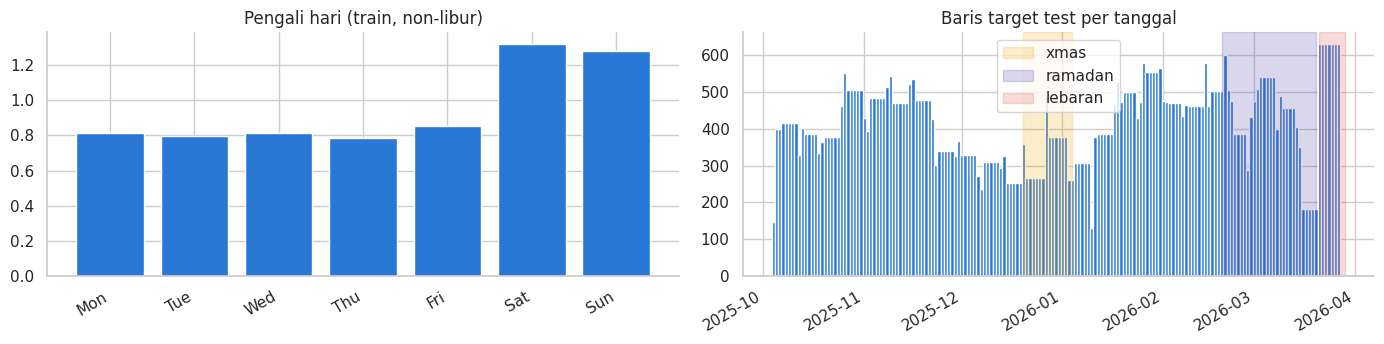

In [9]:
DOW = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
x = train.set_index('date_show').groupby(KEY).total_ticket.apply(lambda s: s.asfreq('D', fill_value=0)).reset_index()
x['m7'] = x.groupby(KEY).total_ticket.transform(lambda s: s.rolling(7, center=True).mean())
x = x[(x.m7 >= 20) & ~x.date_show.isin(CFG.OUTAGE)].merge(hol, left_on='date_show', right_on='date', how='left')
x['mult'] = x.total_ticket / x.m7
day = x.groupby('date_show').agg(mult=('mult', 'median'), hol=('holiday_tipe', 'first'), name=('holiday_name', 'first'))
day['dow'] = day.index.dayofweek
prof = day[day.hol == 'normal'].groupby('dow').mult.median()
day['excess'] = day.mult / day.dow.map(prof)
print('weekday multiplier:', dict(zip(DOW, prof.round(3))))
display(day[day.hol == 'holiday'][['name', 'dow', 'excess']].round(2))

SEGMENTS = {'xmas': ('2025-12-20', '2026-01-04'), 'ramadan': ('2026-02-19', '2026-03-20'), 'lebaran': ('2026-03-21', '2026-03-29')}
for n, (a, b) in SEGMENTS.items():
    m = test.date_show.between(a, b)
    print(f'{n:8s} test rows {m.sum():6d} ({m.mean():.1%}), films {test[m].movie_title.nunique()}')

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].bar(DOW, prof.values, color=PAL[0]); ax[0].set(title='Pengali hari (train, non-libur)')
cnt = test.groupby('date_show').size()
ax[1].bar(cnt.index, cnt.values, width=1, color=PAL[0])
for (n, (a, b)), c in zip(SEGMENTS.items(), [PAL[3], PAL[6], PAL[7]]):
    ax[1].axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=.2, label=n)
ax[1].set(title='Baris target test per tanggal'); ax[1].legend()
fig.autofmt_xdate(); plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'calendar.png'); plt.show()

#### Insights

> Sabtu dan Minggu sekitar 1,6 kali hari kerja, libur di hari kerja setara akhir pekan, libur di akhir pekan hampir tidak menambah. Sekitar 30% baris uji berada di periode yang tidak pernah ada di train: Ramadan (17,1%), libur Natal dan Tahun Baru (7,2%), dan Lebaran (6,1%). Efek kalender karena itu dimasukkan secara struktural sebagai pengali target, bukan dipelajari pohon keputusan yang tidak bisa ekstrapolasi.

## Level Pasar dan Ukuran Pasangan

Okupansi median per bulan dan distribusi skala pasangan D1 sampai D3 dibandingkan antara train dan data uji. Skala dihitung dengan rumus resmi pada seluruh pasangan yang laku di D3.

test pairs by scale bucket: {Interval(0.0, 5.0, closed='right'): 0.015, Interval(5.0, 20.0, closed='right'): 0.114, Interval(20.0, 50.0, closed='right'): 0.198, Interval(50.0, 100.0, closed='right'): 0.2, Interval(100.0, 200.0, closed='right'): 0.195, Interval(200.0, 500.0, closed='right'): 0.178, Interval(500.0, 1000000000.0, closed='right'): 0.1}


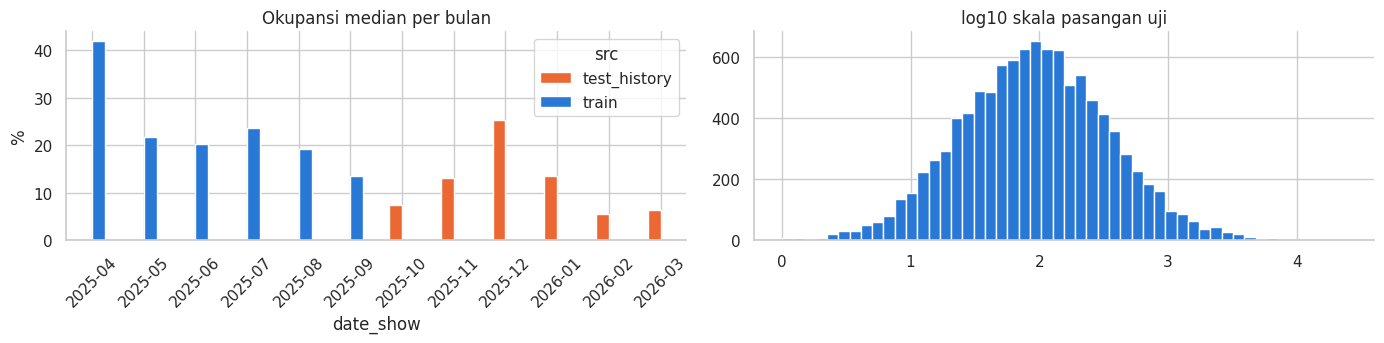

In [10]:
occ = pd.concat([train.assign(src='train'), hist.assign(src='test_history')])
occ_m = occ.groupby([occ.date_show.dt.to_period('M'), 'src']).occupation_rate.median().unstack()
s_te = (hist.groupby(KEY).total_ticket.sum() / 3).clip(lower=1).reindex(pd.MultiIndex.from_frame(test[KEY].drop_duplicates()))
bins = CFG.TW_BINS
print('test pairs by scale bucket:', pd.cut(s_te, bins).value_counts(normalize=True).sort_index().round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
occ_m.plot.bar(ax=ax[0], rot=45, color=[PAL[1], PAL[0]]); ax[0].set(title='Okupansi median per bulan', ylabel='%')
ax[1].hist(np.log10(s_te), bins=50, color=PAL[0]); ax[1].set(title='log10 skala pasangan uji')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'market.png'); plt.show()

#### Insights

> Okupansi median Oktober 2025 (7,6%), Februari (5,5%), dan Maret 2026 (6,4%) berada di bawah semua bulan train (13,6% sampai 41,8%). Pasar periode uji jauh lebih sepi, sehingga pasangan uji jauh lebih kecil: 13% baris uji memiliki skala di bawah 20. Konsekuensinya diukur di Bagian 6 dan Bagian 8.

---

# Data Cleaning <a name="5"></a>

---

Target dibentuk dengan zero-fill, sehingga hari ketika sistem pelaporan mati akan menjadi nol palsu. Selain itu, akhir pekan pratinjau berbayar sebelum rilis resmi dapat terbaca sebagai D1.

dates with no data: [datetime.date(2025, 6, 13)]
dates with < 70% of clusters reporting: {Timestamp('2025-06-07 00:00:00'): 10.0, Timestamp('2025-06-09 00:00:00'): 1.0, Timestamp('2025-06-10 00:00:00'): 67.0, Timestamp('2025-06-11 00:00:00'): 76.0, Timestamp('2025-06-16 00:00:00'): 62.0}
A MINECRAFT MOVIE coverage 1-10 Apr: {Timestamp('2025-04-04 00:00:00'): 55, Timestamp('2025-04-05 00:00:00'): 68, Timestamp('2025-04-06 00:00:00'): 67, Timestamp('2025-04-09 00:00:00'): 93, Timestamp('2025-04-10 00:00:00'): 91}


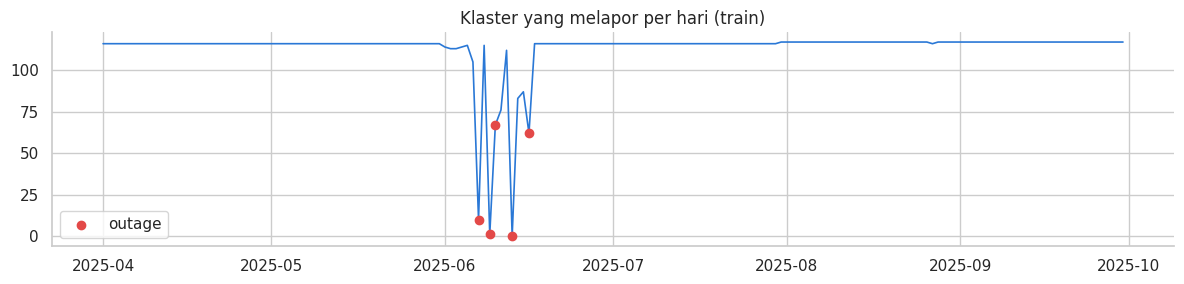

In [11]:
rep = train.groupby('date_show').cinema_ids.nunique().reindex(pd.date_range('2025-04-01', CFG.TRAIN_END))
print('dates with no data:', rep[rep.isna()].index.date.tolist())
print('dates with < 70% of clusters reporting:', rep[rep < 0.7 * rep.median()].to_dict())
mc = train[train.movie_title == 'A MINECRAFT MOVIE'].groupby('date_show').cinema_ids.nunique()
print('A MINECRAFT MOVIE coverage 1-10 Apr:', mc.loc[:'2025-04-10'].to_dict())
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(rep.index, rep.fillna(0), lw=1.2)
ax.scatter(CFG.OUTAGE, rep.reindex(CFG.OUTAGE).fillna(0), color=PAL[7], zorder=3, label='outage')
ax.set(title='Klaster yang melapor per hari (train)'); ax.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'outage.png'); plt.show()

#### Insights

> Lima tanggal Juni 2025 adalah outage pelaporan (13 Juni kosong, 9 Juni hanya 1 klaster). Baris target pada tanggal tersebut dibuang dan film yang D1 sampai D3-nya menyentuh outage tidak dijadikan sampel. A MINECRAFT MOVIE memiliki pratinjau 4 sampai 6 April lalu jeda sebelum rilis resmi 9 April: D1 dicari hanya di dalam segmen tayang kontinu yang memuat puncak cakupan.

---

# Preprocessing <a name="6"></a>

---

`train.csv` tidak memiliki penanda D1 sampai D10. Aturan panitia direplikasi: D1 rilis resmi, rilis luas, pasangan laku di D3, target nol diisi eksplisit. Hasilnya diverifikasi terhadap data uji, termasuk dengan tugas proxy yang memiliki label di dalam periode uji.

## Rekonstruksi D1 dan Simulasi Sampel

D1 adalah hari pertama cakupan klaster judul dasar mencapai 50% puncak, dicari di dalam segmen tayang kontinu yang memuat puncak. Judul dengan cakupan D1 di bawah 25 klaster dipisahkan sebagai film rilis terbatas: tidak pernah dievaluasi, tetapi dipakai sebagai data latih tambahan untuk pasangan kecil.

In [12]:
def release_dates(tx, frac=CFG.D1_FRAC, min_nc=CFG.MIN_NC):
    x = tx.assign(base=base_title(tx.movie_title))
    nc = x.groupby(['base', 'date_show']).cinema_ids.nunique()
    out = {}
    for b, s in nc.groupby(level=0):
        s = s.droplevel(0)
        s = s.reindex(pd.date_range(s.index.min(), s.index.max()), fill_value=0)
        pk = s.idxmax()
        z = s[:pk][s[:pk] == 0]
        seg = s[z.index.max() + pd.Timedelta(days=1):] if len(z) else s
        c = seg[seg >= frac * s.max()]
        if len(c) and c.iloc[0] >= min_nc:
            out[b] = c.index[0]
    t = x.drop_duplicates('movie_title').set_index('movie_title').base
    return t.map(pd.Series(out, dtype='datetime64[ns]')).dropna().rename('d1')


def simulate(tx, d1, last_date=CFG.TRAIN_END, bad=CFG.OUTAGE):
    d1 = d1[d1 + pd.Timedelta(days=9) <= last_date]
    if len(bad):
        d1 = d1[~np.any([(d1 <= b) & (d1 + pd.Timedelta(days=2) >= b) for b in bad], axis=0)]
    x = tx.merge(d1, left_on='movie_title', right_index=True)
    x['d'] = (x.date_show - x.d1).dt.days + 1
    hs = x[x.d.between(1, 3)].drop(columns=['d1', 'd']).reset_index(drop=True)
    pairs = x.loc[x.d == 3, KEY].drop_duplicates().merge(d1, left_on='movie_title', right_index=True)
    tg = pairs.loc[pairs.index.repeat(7)].copy()
    tg['date_show'] = tg.d1 + pd.to_timedelta(np.tile(np.arange(3, 10), len(pairs)), unit='D')
    y = x[x.d.between(4, 10)][KEY + ['date_show', 'total_ticket']]
    tg = tg.merge(y, on=KEY + ['date_show'], how='left').fillna({'total_ticket': 0})
    tg = tg[~tg.date_show.isin(bad)]
    tg['city_name'] = tg.cinema_ids.map(tx.drop_duplicates('cinema_ids').set_index('cinema_ids').city_name)
    return hs, tg.drop(columns='d1').reset_index(drop=True)


def pair_scale(h):
    return (h.groupby(KEY).total_ticket.sum() / 3).clip(lower=1).rename('scale')


def mase(y, p, s):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(p)) / np.asarray(s)))


first = train.groupby('movie_title').date_show.min()
running = first[first == first.min()].index
D_wide = release_dates(train)
D_lim = release_dates(train, CFG.D1_FRAC, 0).drop(D_wide.index, errors='ignore').drop(running, errors='ignore')
hs, ts = simulate(train, D_wide.drop(running, errors='ignore'))
hl, tl = simulate(train, D_lim)
print(f'wide releases: {ts.movie_title.nunique()} films, {len(ts)} target rows | limited (train only): {tl.movie_title.nunique()} films, {len(tl)} rows')
print('A MINECRAFT MOVIE D1:', D_wide['A MINECRAFT MOVIE'].date())

wide releases: 143 films, 56372 target rows | limited (train only): 36 films, 1435 rows
A MINECRAFT MOVIE D1: 2025-04-09


Fungsi `simulate` diuji pada film sintetis: klaster B tidak laku di D3 sehingga harus dibuang, dan hari tanpa transaksi harus menjadi nol.

In [13]:
dd = pd.date_range('2025-05-01', periods=12)
toy = pd.DataFrame({'date_show': list(dd) + [dd[0], dd[1]], 'cinema_ids': ['A'] * 12 + ['B', 'B'], 'city_name': 'X',
                    'movie_title': 'M', 'total_ticket': list(range(1, 13)) + [5, 5], 'occupation_rate': 1.0,
                    'total_show': 1}).drop(index=5)
th_, tg_ = simulate(toy, pd.Series({'M': dd[0]}, name='d1'), bad=pd.DatetimeIndex([]))
assert set(tg_.cinema_ids) == {'A'} and tg_.total_ticket.tolist() == [4, 5, 0, 7, 8, 9, 10]
assert np.isclose(pair_scale(th_)[('M', 'B')], 10 / 3)
print('simulate() self-check passed')

simulate() self-check passed


#### Insights

> Aturan D1 memakai puncak cakupan sepanjang riwayat film, yaitu informasi masa depan. Audit lokal (`eda/53`) membandingkannya dengan aturan yang benar-benar kausal: D1 = hari pertama yang jendela D1 sampai D3-nya sendiri memiliki minimal 25 klaster setiap hari, tanpa melihat puncak. Aturan itu memindahkan 6 film (A MINECRAFT MOVIE ke pratayang berbayar 4 April, BELIEVE 20 hari lebih awal), mengubah skala 191 pasangan bersama (varian yang masih memakai segmen puncak: 125), dan membuang 15 film yang dibuka di minimal 25 klaster lalu runtuh di D2 sampai D3 (rasio cakupan D3/D1 median 0,34, misalnya ARTI CINTA 52 menjadi 2 klaster). Jarak KS rasio cakupan ke data uji memang turun (0,196 menjadi 0,106), tetapi hanya karena ekor bawah itu dibuang.

> Data uji justru memuat pembukaan yang runtuh seperti itu: 8 film uji punya hari dengan kurang dari 25 klaster (SEND HELP 52, 49, lalu 1 klaster; G-DRAGON IN CINEMA 55, 30, 3) dan 30 film uji memiliki rasio cakupan D3/D1 di bawah 0,8. Seleksi panitia karena itu konsisten dengan aturan cakupan D1 (aturan sekarang), bukan dengan syarat jendela lebar tiga hari. Aturan D1 dipertahankan dengan dasar ini, bukan karena perubahannya kecil.

## Verifikasi: Komposisi dan Periode Uji

Sampel simulasi dibandingkan dengan data uji. Karena target uji tidak tersedia, dibuat tugas proxy yang memiliki label di **dalam periode uji**: memprediksi D3 dari D1 dan D2. Model proxy dilatih pada train, lalu galatnya per bucket skala dibandingkan antara validasi silang train dan periode uji.

,train_share,test_share,train_cv_mase,test_period_mase,train_zero_D3,test_zero_D3
s,,,,,,
"(0.0, 5.0]",0.004,0.024,1.062,1.171,0.771,0.544
"(5.0, 20.0]",0.053,0.134,0.750,0.693,0.568,0.308
"(20.0, 50.0]",0.134,0.208,0.612,0.587,0.392,0.107
"(50.0, 100.0]",0.173,0.195,0.533,0.481,0.129,0.028
"(100.0, 200.0]",0.217,0.185,0.418,0.410,0.031,0.011
"(200.0, 500.0]",0.249,0.160,0.342,0.344,0.004,0.002
"(500.0, 1000000000.0]",0.170,0.093,0.355,0.285,0.002,0.000


proxy MASE: train CV 0.4544 | re-weighted to test scale mix 0.5232 | real test period 0.4950


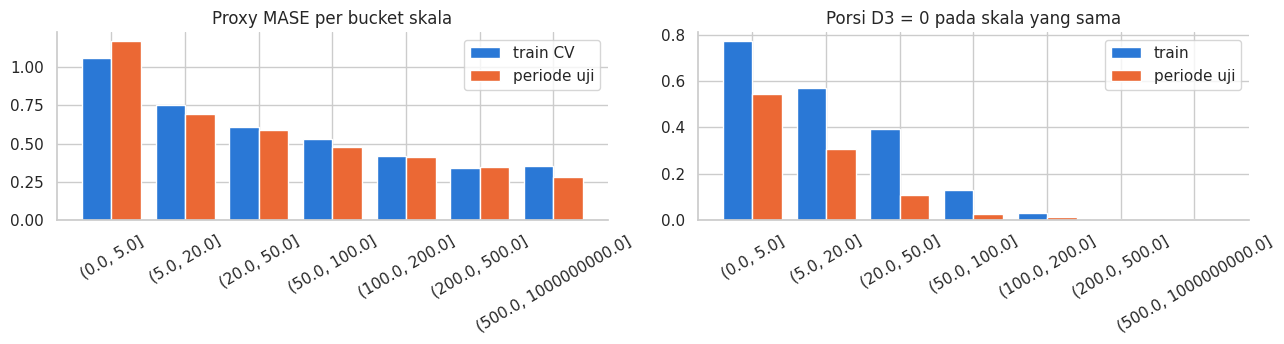

In [14]:
def proxy(hh):
    d1 = hh.groupby('movie_title').date_show.min().rename('d1')
    x = hh.join(d1, on='movie_title')
    x['d'] = (x.date_show - x.d1).dt.days + 1
    P = x.pivot_table(index=KEY, columns='d', values='total_ticket', fill_value=0).reindex(columns=[1, 2, 3], fill_value=0)
    S = x.pivot_table(index=KEY, columns='d', values='total_show', fill_value=0).reindex(columns=[1, 2], fill_value=0)
    O = x.pivot_table(index=KEY, columns='d', values='occupation_rate', fill_value=0).reindex(columns=[1, 2], fill_value=0)
    P = P[P[2] > 0]
    f = pd.DataFrame({'s': ((P[1] + P[2]) / 2).clip(lower=1), 'y': P[3]}, index=P.index)
    f['q1'], f['q2'], f['log_s'] = P[1] / f.s, P[2] / f.s, np.log1p(f.s)
    f['sh1'], f['sh2'] = S.reindex(P.index)[1], S.reindex(P.index)[2]
    f['sh_tr'] = (f.sh2 + 1) / (f.sh1 + 1)
    f['occ2'] = O.reindex(P.index)[2]
    f = f.reset_index().join(d1, on='movie_title')
    g = x[x.d <= 2].groupby(['movie_title', 'd']).total_ticket.sum().unstack().reindex(columns=[1, 2], fill_value=0)
    f['f_tr'] = f.movie_title.map((g[2] + 1) / (g[1] + 1))
    f['f_log'] = f.movie_title.map(np.log1p(g.mean(axis=1)))
    f['f_nc'] = f.movie_title.map(x[x.d == 2].groupby('movie_title').cinema_ids.nunique())
    f['d1_dow'] = f.d1.dt.dayofweek
    return f


PA, PB = proxy(hs), proxy(hist)
pc = ['q1', 'q2', 'log_s', 'sh_tr', 'f_tr', 'f_log', 'd1_dow']
pm = dict(objective='l1', n_estimators=400, learning_rate=0.03, num_leaves=31, min_child_samples=100, verbose=-1, deterministic=True, force_row_wise=True)
oofA = np.zeros(len(PA))
for a, b in GroupKFold(5).split(PA, groups=base_title(PA.movie_title)):
    m = lgb.LGBMRegressor(**pm, random_state=CFG.SEED).fit(PA.iloc[a][pc], PA.y.iloc[a] / PA.s.iloc[a])
    oofA[b] = np.clip(m.predict(PA.iloc[b][pc]), 0, None) * PA.s.values[b]
m = lgb.LGBMRegressor(**pm, random_state=CFG.SEED).fit(PA[pc], PA.y / PA.s)
pB = np.clip(m.predict(PB[pc]), 0, None) * PB.s.values
eA, eB = np.abs(PA.y - oofA) / PA.s, np.abs(PB.y - pB) / PB.s
cutA, cutB = pd.cut(PA.s, bins), pd.cut(PB.s, bins)
tab = pd.DataFrame({'train_share': cutA.value_counts(normalize=True), 'test_share': cutB.value_counts(normalize=True),
                    'train_cv_mase': eA.groupby(cutA, observed=False).mean(), 'test_period_mase': eB.groupby(cutB, observed=False).mean(),
                    'train_zero_D3': (PA.y == 0).groupby(cutA, observed=False).mean(), 'test_zero_D3': (PB.y == 0).groupby(cutB, observed=False).mean()}).sort_index()
display(tab.round(3))
print(f'proxy MASE: train CV {eA.mean():.4f} | re-weighted to test scale mix {(tab.test_share * tab.train_cv_mase).sum():.4f} | real test period {eB.mean():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
xx = np.arange(len(tab))
ax[0].bar(xx - .2, tab.train_cv_mase, .4, label='train CV'); ax[0].bar(xx + .2, tab.test_period_mase, .4, label='periode uji')
ax[0].set_xticks(xx, [str(i) for i in tab.index], rotation=30); ax[0].set(title='Proxy MASE per bucket skala'); ax[0].legend()
ax[1].bar(xx - .2, tab.train_zero_D3, .4, label='train'); ax[1].bar(xx + .2, tab.test_zero_D3, .4, label='periode uji')
ax[1].set_xticks(xx, [str(i) for i in tab.index], rotation=30); ax[1].set(title='Porsi D3 = 0 pada skala yang sama'); ax[1].legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'proxy.png'); plt.show()

#### Insights

> Galat per bucket skala hampir sama antara validasi silang train dan periode uji, tetapi data uji memuat jauh lebih banyak pasangan kecil yang galatnya terbesar. Karena itu metrik keputusan adalah **TW-MASE**. TW-MASE v2 (0,377) dan v3 (0,388) memberi peringkat yang sama dengan leaderboard (0,4506 dan 0,4573), tetapi keduanya berjarak tetap sekitar 0,07.

> Pada skala absolut yang sama, porsi pasangan yang berhenti di D3 jauh lebih kecil di periode uji (skala 20 sampai 50: 0,39 di train vs 0,11 di uji). Bagian berikut menguji apakah ini efek musim atau perubahan perilaku bioskop.

## Kebijakan Pencopotan di Periode Uji

Porsi pasangan yang berhenti laku di D3 dibandingkan pada **permintaan per pertunjukan yang sama** (tiket per show D1 sampai D2), sehingga perbedaan ukuran pasar tidak ikut terhitung. Besarnya pergeseran diestimasi di Bagian 8 setelah kalender tersedia.

,train_drop_D3,test_drop_D3,train_n,test_n
"(0.226, 7.8]",0.499,0.219,948,3070
"(7.8, 14.833]",0.256,0.063,1393,2605
"(14.833, 25.2]",0.085,0.030,1795,2221
"(25.2, 44.9]",0.023,0.014,2296,1702
"(44.9, 425.167]",0.002,0.005,2531,1476


D3 stop rate by release month: {Period('2025-04', 'M'): 0.082, Period('2025-05', 'M'): 0.13, Period('2025-06', 'M'): 0.173, Period('2025-07', 'M'): 0.083, Period('2025-08', 'M'): 0.137, Period('2025-09', 'M'): 0.096, Period('2025-10', 'M'): 0.096, Period('2025-11', 'M'): 0.08, Period('2025-12', 'M'): 0.062, Period('2026-01', 'M'): 0.081, Period('2026-02', 'M'): 0.107, Period('2026-03', 'M'): 0.066}


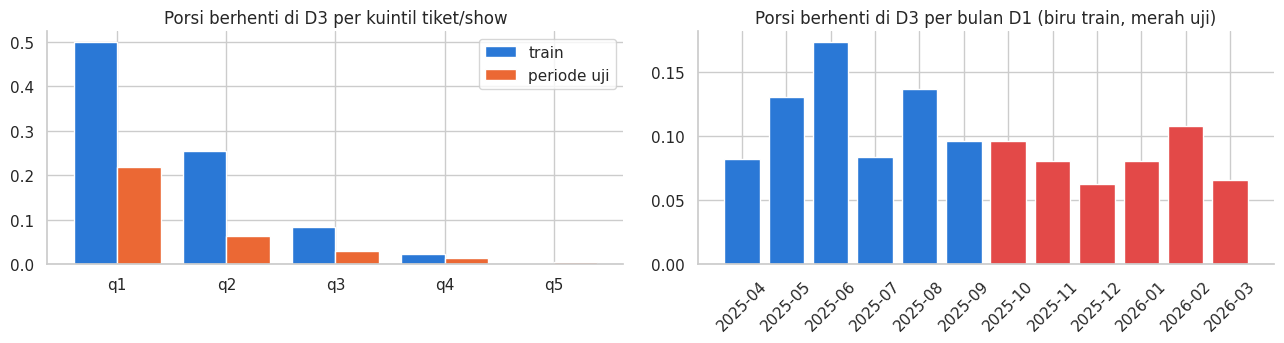

In [15]:
DA = PA.assign(z=PA.y == 0, tps=PA.s * 2 / (PA.sh1 + PA.sh2).clip(lower=1))
DB = PB.assign(z=PB.y == 0, tps=PB.s * 2 / (PB.sh1 + PB.sh2).clip(lower=1))
q = pd.qcut(pd.concat([DA.tps, DB.tps]), 5)
qa, qb = q.iloc[:len(DA)].values, q.iloc[len(DA):].values
tq = pd.DataFrame({'train_drop_D3': DA.z.groupby(qa, observed=False).mean(), 'test_drop_D3': DB.z.groupby(qb, observed=False).mean(),
                   'train_n': pd.Series(qa).value_counts(), 'test_n': pd.Series(qb).value_counts()})
display(tq.round(3))
zm = pd.concat([DA.assign(m=DA.d1.dt.to_period('M')), DB.assign(m=DB.d1.dt.to_period('M'))]).groupby('m').z.mean()
print('D3 stop rate by release month:', zm.round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
xx = np.arange(len(tq))
ax[0].bar(xx - .2, tq.train_drop_D3, .4, label='train'); ax[0].bar(xx + .2, tq.test_drop_D3, .4, label='periode uji')
ax[0].set_xticks(xx, [f'q{i + 1}' for i in xx]); ax[0].set(title='Porsi berhenti di D3 per kuintil tiket/show'); ax[0].legend()
ax[1].bar(zm.index.astype(str), zm.values, color=[PAL[0] if str(m) < '2025-10' else PAL[7] for m in zm.index])
ax[1].set(title='Porsi berhenti di D3 per bulan D1 (biru train, merah uji)'); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'pull_policy.png'); plt.show()

#### Insights

> Pada tiket per show absolut yang sama, porsi pasangan yang berhenti di D3 di periode uji hanya sekitar setengah sampai seperempat porsi train. Sejak v4 ini dibaca sebagai perubahan kebijakan bioskop dan dikoreksi dengan $\lambda a$. Tetapi porsi berhenti per bulan tetap 5 sampai 17% di kedua periode walaupun okupansi periode uji turun ke separuhnya (Februari 2026: okupansi median 5%, porsi berhenti tetap sekitar 10%). Ambang absolut yang konstan tidak menghasilkan pola itu; bagian berikut menguji penjelasan lain.

> Di train, kecenderungan klaster mencopot di D3 juga hampir tidak terbawa ke nol D4 sampai D10: klaster yang 1 logit lebih "lengket" di D3 hanya 0,09 logit lebih lengket di D4 sampai D10 setelah koreksi reliabilitas (`eda/67`, 116 klaster). Jadi besar pergeseran di D3 tidak bisa dipindahkan begitu saja ke horizon target.

## Tolok Ukur Relatif: Pergeseran Kebijakan atau Pasar yang Sepi?

Bila bioskop memutuskan mencopot film berdasarkan kinerjanya **dibanding film lain di bioskop yang sama**, maka di pasar yang sepi semua film terlihat kecil secara absolut, tetapi yang dicopot tetap yang paling lemah secara relatif. Tiket per show setiap pasangan dibagi median tiket per show film lain di klaster yang sama yang D1-nya berjarak paling jauh 14 hari. Referensi hanya memakai jendela D1 sampai D3 film lain (train dan `test_history`), informasi yang sama di kedua periode. Tabel lookup desil dibangun dari train, lalu offset logit periode uji dihitung untuk kedua tolok ukur.

,test_pairs,expected_test,observed_test,logit_offset
absolute tickets/show,11074.0,0.220,0.085,-1.31
tickets/show vs other films in cluster,11066.0,0.115,0.085,-0.44


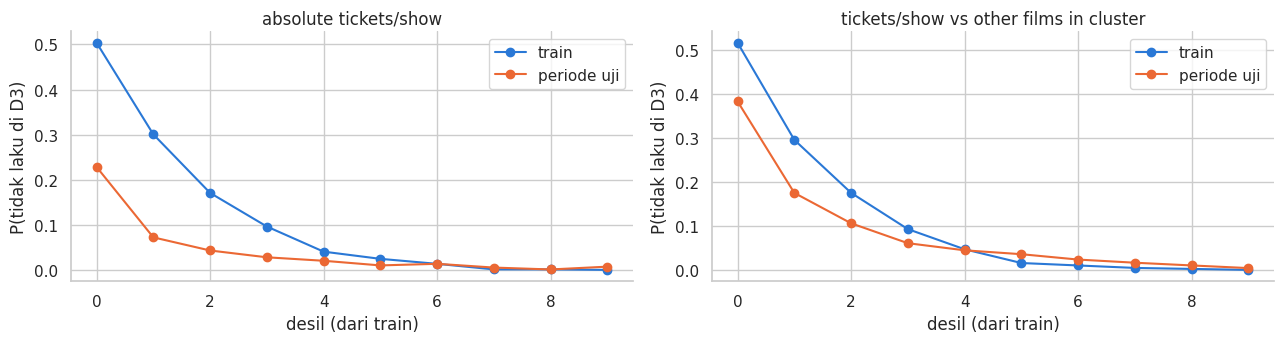

In [16]:
def visible_windows(tx, d1):
    x = tx.merge(d1.rename('d1'), left_on='movie_title', right_index=True)
    return x[(x.date_show >= x.d1) & (x.date_show <= x.d1 + pd.Timedelta(days=2))].drop(columns='d1')


def make_pools(vis):
    v = vis.assign(base=base_title(vis.movie_title))
    d1_ = v.groupby('base').date_show.min().rename('d1')
    vp = v.groupby(['base', 'cinema_ids']).agg(tix=('total_ticket', 'sum'), shows=('total_show', 'sum')).reset_index().join(d1_, on='base')
    vp['sc'], vp['tps'] = vp.tix / 3, vp.tix / vp.shows.clip(lower=1)
    vf = (v.groupby('base').total_ticket.sum() / 3).rename('ft').to_frame().join(d1_).reset_index()
    return vp, vf


vis_tr = visible_windows(train, D_wide)
VP, VF = make_pools(pd.concat([vis_tr, hist], ignore_index=True))


def ref_cluster(Q, col, pool, win=CFG.REL_WIN, min_n=2):
    q = Q[['movie_title', 'cinema_ids', 'd1']].drop_duplicates()
    q = q.assign(base=base_title(q.movie_title))
    m = q.merge(pool[['base', 'cinema_ids', 'd1', col]].rename(columns={'base': 'base_o', 'd1': 'd1_o'}), on='cinema_ids')
    m = m[((m.d1 - m.d1_o).dt.days.abs() <= win) & (m.base != m.base_o)]
    g = m.groupby(['movie_title', 'cinema_ids'])[col].agg(['median', 'size'])
    med = g['median'].where(g['size'] >= min_n)
    return pd.MultiIndex.from_frame(Q[['movie_title', 'cinema_ids']]).map(med).values.astype(float)


def ref_national(Q, pool, col, win=CFG.REL_WIN):
    fd = Q.drop_duplicates('movie_title').set_index('movie_title').d1
    fb = base_title(pd.Series(fd.index, index=fd.index))
    days = pool.d1.values.astype('datetime64[D]').astype(np.int64)
    out = {}
    for m_, t_ in fd.items():
        k = (np.abs(days - np.datetime64(t_, 'D').astype(np.int64)) <= win) & (pool.base.values != fb[m_])
        out[m_] = np.median(pool[col].values[k])
    return Q.movie_title.map(out).values.astype(float)


logit = lambda p: np.log(p / (1 - p))
sigm = lambda t: 1 / (1 + np.exp(-t))
nll = lambda p, z, a: -np.mean(z * np.log(sigm(logit(p) + a)) + (1 - z) * np.log(1 - sigm(logit(p) + a)))
grid_a = np.linspace(-4, 2, 601)
for D_ in (DA, DB):
    D_['tps_clu'] = D_.tps / ref_cluster(D_, 'tps', VP)


def stop_lookup(col):
    a_, b_ = DA.dropna(subset=[col]), DB.dropna(subset=[col])
    e = np.unique(np.quantile(np.log(a_[col].clip(lower=1e-3)), np.linspace(0, 1, 11)))
    bin_ = lambda D_: np.clip(np.searchsorted(e, np.log(D_[col].clip(lower=1e-3)), side='right') - 1, 0, len(e) - 2)
    look = a_.z.groupby(bin_(a_)).mean()
    pe = np.clip(pd.Series(bin_(b_)).map(look).values, 1e-3, 1 - 1e-3)
    zb = b_.z.values.astype(float)
    off = float(grid_a[np.argmin([nll(pe, zb, a) for a in grid_a])])
    curves = pd.DataFrame({'train': look, 'test': b_.z.groupby(bin_(b_)).mean()})
    return dict(test_pairs=len(b_), expected_test=pe.mean(), observed_test=zb.mean(), logit_offset=off), curves


YARD = {'absolute tickets/show': 'tps', 'tickets/show vs other films in cluster': 'tps_clu'}
yard = {k: stop_lookup(c) for k, c in YARD.items()}
display(pd.DataFrame({k: v[0] for k, v in yard.items()}).T.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a_, (k, (_, cv)) in zip(ax, yard.items()):
    a_.plot(cv.index, cv.train, marker='o', label='train'); a_.plot(cv.index, cv.test, marker='o', label='periode uji')
    a_.set(title=k, xlabel='desil (dari train)', ylabel='P(tidak laku di D3)'); a_.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'stop_yardstick.png'); plt.show()

#### Insights

> Dengan tolok ukur absolut, peluang berhenti di D3 pada desil terbawah sekitar 0,50 di train tetapi 0,22 di periode uji (offset logit sekitar -1,3). Dengan tolok ukur relatif terhadap film lain di klaster yang sama, kurva periode uji mendekati kurva train dan offset menyusut ke sekitar -0,4 di sel ini (referensi D1 sampai D3 semua film yang terlihat) atau -0,2 di analisis lokal `eda/68` (referensi D1 sampai D2 pasangan proxy), dengan daya pisah di train yang sama (log-loss 0,227 vs 0,230). Sisa selisih ada di dua desil terbawah (sekitar 0,38 vs 0,52), jadi tidak seluruh pergeseran adalah artefak, tetapi sebagian besarnya berasal dari mengukur film dengan penggaris absolut di pasar yang levelnya turun ke separuh. Sisa pergeseran itu diukur ulang di Bagian 8 dengan fitur yang sama dengan model, dan koreksi $\lambda a$ tetap diuji per model.

> Konsekuensinya lebih luas dari keputusan mencopot. Model yang memakai level absolut (`log_s`, `f_logT`) membaca pasangan uji yang kecil karena pasar sepi sebagai pasangan yang sedang mati, sehingga semua model, apa pun arsitekturnya, menebak terlalu rendah dengan arah yang sama. Ini cocok dengan offset leaderboard yang sama untuk semua versi. Bagian 7 membangun fitur level relatif, dan Bagian 8 mengujinya dengan label periode uji.

## Binomial Thinning: Periode Uji sebagai Pasar dengan Pembeli Lebih Sedikit

Tolok ukur relatif menjelaskan sebagian pergeseran, tetapi bukan semuanya. Hipotesis yang lebih sederhana: periode uji adalah pasar yang sama dengan pembeli lebih sedikit. Bioskop, jadwal show, dan dinamika film sama, hanya setiap tiket train "terjual" dengan peluang $\pi$. Ini disimulasikan dengan binomial thinning seluruh transaksi train ($y' \sim \text{Binomial}(y, \pi)$, okupansi ikut diskalakan, jumlah show tetap karena show per pasangan di periode uji sama dengan train, median 5). D1 tetap dari data mentah, lalu aturan panitia diterapkan ulang. Pembanding yang benar adalah label periode uji (D3 dari D1 dan D2), bukan pasangan kecil train yang memang sedang mati. Thinning pernah ditolak di `eda/14` justru karena dibandingkan dengan pasangan kecil train.

share


,train raw,test period,thinned 0.35,thinned 0.5,thinned 0.7
s,,,,,
"(0.0, 5.0]",0.004,0.024,0.033,0.018,0.010
"(5.0, 10.0]",0.013,0.042,0.064,0.040,0.025
"(10.0, 20.0]",0.040,0.092,0.117,0.091,0.062
"(20.0, 50.0]",0.134,0.208,0.247,0.216,0.177
"(50.0, 200.0]",0.390,0.380,0.390,0.411,0.412
"(200.0, 1000000000.0]",0.420,0.253,0.149,0.224,0.315


P(D3=0)


,train raw,test period,thinned 0.35,thinned 0.5,thinned 0.7
s,,,,,
"(0.0, 5.0]",0.771,0.544,0.590,0.671,0.651
"(5.0, 10.0]",0.621,0.403,0.504,0.548,0.629
"(10.0, 20.0]",0.552,0.264,0.312,0.430,0.495
"(20.0, 50.0]",0.392,0.107,0.091,0.161,0.265
"(50.0, 200.0]",0.074,0.019,0.009,0.019,0.038
"(200.0, 1000000000.0]",0.003,0.001,0.002,0.001,0.002


median y3/s


,train raw,test period,thinned 0.35,thinned 0.5,thinned 0.7
s,,,,,
"(0.0, 5.0]",0.000,0.000,0.000,0.000,0.000
"(5.0, 10.0]",0.000,0.333,0.000,0.000,0.000
"(10.0, 20.0]",0.000,0.550,0.542,0.328,0.053
"(20.0, 50.0]",0.392,0.762,0.827,0.741,0.651
"(50.0, 200.0]",0.850,0.898,0.890,0.896,0.877
"(200.0, 1000000000.0]",0.894,0.934,0.888,0.889,0.890


,expected_test,observed_test,logit_offset,test_logloss
raw,0.220,0.085,-1.31,0.325
raw + thinned,0.128,0.085,-0.56,0.250
thinned only,0.110,0.085,-0.37,0.246


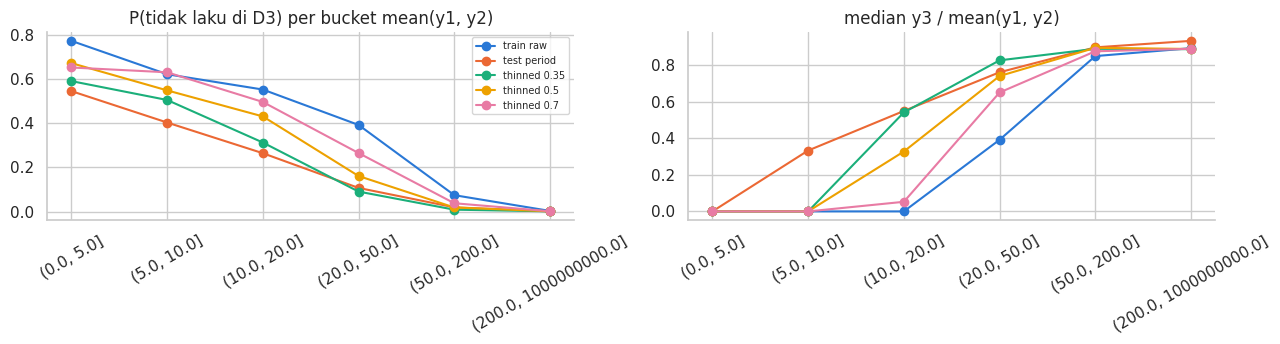

In [17]:
def thin_tx(tx, pi, seed):
    t = tx.copy()
    yb = np.random.default_rng(seed).binomial(t.total_ticket.values.astype(np.int64), pi)
    t['occupation_rate'] = t.occupation_rate * yb / t.total_ticket
    t['total_ticket'] = yb
    return t[t.total_ticket > 0].reset_index(drop=True)


TX_T = {pi: thin_tx(train, pi, sd) for pi, sd in zip(CFG.THIN_PIS, CFG.THIN_SEEDS)}
TX_Q = thin_tx(train, CFG.VAL_PI, CFG.VAL_SEED)
HS_T = {pi: simulate(tx_, D_wide.drop(running, errors='ignore'))[0] for pi, tx_ in TX_T.items()}
PA_T = pd.concat([proxy(h_).assign(world=pi) for pi, h_ in HS_T.items()], ignore_index=True)
BK = [0, 5, 10, 20, 50, 200, 1e9]
rows = []
for name, P_ in [('train raw', PA), ('test period', PB)] + [(f'thinned {pi}', PA_T[PA_T.world == pi]) for pi in CFG.THIN_PIS]:
    g = P_.groupby(pd.cut(P_.s, BK), observed=False)
    rows.append(pd.DataFrame({'share': g.size() / len(P_), 'P(D3=0)': g.y.apply(lambda v: (v == 0).mean()),
                              'median y3/s': g.apply(lambda q: np.median(q.y / q.s), include_groups=False)}).assign(world=name))
WORLD_ORDER = ['train raw', 'test period'] + [f'thinned {pi}' for pi in CFG.THIN_PIS]
TB = pd.concat(rows).reset_index().pivot(index='s', columns='world')
TB = TB.reindex(columns=pd.MultiIndex.from_product([['share', 'P(D3=0)', 'median y3/s'], WORLD_ORDER]))
for metric_ in ['share', 'P(D3=0)', 'median y3/s']:
    print(metric_); display(TB[metric_].round(3))

DA_T = PA_T.assign(z=PA_T.y == 0, tps=PA_T.s * 2 / (PA_T.sh1 + PA_T.sh2).clip(lower=1))


def stop_offset(train_set):
    e = np.quantile(np.log(train_set.tps.clip(lower=1e-3)), np.linspace(0, 1, 11))
    kb = lambda D_: np.clip(np.searchsorted(e, np.log(D_.tps.clip(lower=1e-3)), side='right') - 1, 0, 9)
    look = train_set.z.groupby(kb(train_set)).mean()
    pe = np.clip(pd.Series(kb(DB)).map(look).values, 1e-3, 1 - 1e-3)
    zb = DB.z.values.astype(float)
    return dict(expected_test=pe.mean(), observed_test=zb.mean(), logit_offset=float(grid_a[np.argmin([nll(pe, zb, a) for a in grid_a])]),
                test_logloss=nll(pe, zb, 0.0))


display(pd.DataFrame({'raw': stop_offset(DA), 'raw + thinned': stop_offset(pd.concat([DA, DA_T], ignore_index=True)),
                      'thinned only': stop_offset(DA_T)}).T.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for w_, c_ in zip(['train raw', 'test period'] + [f'thinned {pi}' for pi in CFG.THIN_PIS], PAL):
    ax[0].plot(range(len(BK) - 1), TB[('P(D3=0)', w_)].values, marker='o', color=c_, label=w_)
    ax[1].plot(range(len(BK) - 1), TB[('median y3/s', w_)].values, marker='o', color=c_, label=w_)
for a_, t_ in zip(ax, ['P(tidak laku di D3) per bucket mean(y1, y2)', 'median y3 / mean(y1, y2)']):
    a_.set_xticks(range(len(BK) - 1), [str(i) for i in pd.IntervalIndex.from_breaks(BK)], rotation=30); a_.set(title=t_)
ax[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'thinning_proxy.png'); plt.show()

#### Insights

> Train mentah tidak bisa mereproduksi periode uji: pada pasangan dengan 20 sampai 50 tiket per hari, peluang tidak laku di D3 0,43 di train tetapi 0,12 di periode uji, dan median rasio D3 0,22 vs 0,57. Dunia thinned dengan $\pi$ 0,35 sampai 0,5 mereproduksinya (analisis lokal `eda/87`: 0,09 sampai 0,17 dan 0,55 sampai 0,63), begitu pula pada bucket 10 sampai 20 dan 50 sampai 200. Tabel lookup yang dilatih pada data thinned memprediksi periode uji lebih baik (MAE 0,3505 menjadi 0,3346).

> Dengan penggaris absolut yang sama, offset pencopotan periode uji menyusut dari sekitar -1,3 ke sekitar -0,3 bila tabelnya dibangun dari dunia thinned (`eda/90`), dan log-loss periode uji turun dari 0,326 ke 0,247. Artinya sebagian besar "kebijakan pencopotan yang berbeda" sebenarnya adalah pasar yang lebih sepi: pasangan yang kecil di periode uji adalah pasangan normal, bukan pasangan sekarat. Sisa offset kecil tetap diuji lewat $\lambda$ per model.

---

# Feature Engineering <a name="7"></a>

---

Satu fungsi `build` dipanggil identik untuk sampel simulasi dan data uji. Fitur hanya memakai informasi yang tersedia pada D3: riwayat D1 sampai D3, kalender resmi, jadwal rilis film lain yang terlihat di jendela D1 sampai D3 masing-masing, statistik klaster dari masa lalu, dan metadata film.

## Data Eksternal: Kalender Resmi

Hanya sumber yang publik paling lambat 30 September 2025 yang dipakai, seluruhnya fakta kalender pemerintah.

| Sumber | Penerbit | Tanggal terbit | Dipakai untuk |
| :--- | :--- | :--- | :--- |
| [SKB 3 Menteri Libur Nasional dan Cuti Bersama 2025](https://www.kemenkopmk.go.id/skb-3-menteri-libur-nasional-dan-cuti-bersama-tahun-2025) | Kemenko PMK | Oktober 2024 (revisi Agustus 2025) | cuti bersama 2025 |
| [SKB 3 Menteri Libur Nasional dan Cuti Bersama 2026](https://setneg.go.id/baca/index/inilah_skb_3_menteri_libur_nasional_dan_cuti_bersama_2026) | Kemensetneg | 19 September 2025 | cuti bersama 2026; 1 Syawal 1447 H = 21 Maret 2026 |
| [Kalender Pendidikan DKI Jakarta 2024/2025](https://tirto.id/kalender-pendidikan-dki-jakarta-tahun-2024-2025-link-unduh-pdf-g1vR) | Disdik DKI via Tirto | 2024 | libur 28 Juni sampai 12 Juli 2025 |
| [Kalender Pendidikan DKI Jakarta 2025/2026 (Kepdis 89/2025)](https://news.detik.com/berita/d-8049756/kalender-pendidikan-semester-ganjil-2025-2026-jakarta-cek-tanggal-pentingnya) | Disdik DKI via Detik | 7 Agustus 2025 | libur 22 sampai 31 Desember 2025 |
| [SE Kadisdik Jabar 21808/PK.02.01.05/Sekre, Pedoman Kalender Pendidikan 2024/2025](https://mmc.tirto.id/documents/2024/06/24/2479-surat-plh-kadisdik-jabar-kalender-pendidikan-2024-2025-1-14062024-025316-signed.pdf) | Disdik Jawa Barat | 10 Juni 2024 | Jawa Barat: libur akhir tahun pelajaran 30 Juni sampai 12 Juli 2025 |
| [SE Kadisdik Jabar 14995/TU.03/PSMA, Pedoman Kalender Pendidikan 2025/2026](https://www.komunitasbelajar.id/2025/06/kalender-pendidikan-provinsi-jawa-barat.html) ([turunan Disdik Ciamis, Juli 2025](https://disdik.ciamiskab.go.id/storage/2025/07/Kaldik_2025-2026_SD-SMP_DISDIK_FIX.pdf)) | Disdik Jawa Barat | 20 Juni 2025 | Jawa Barat: libur semester ganjil 29 Desember 2025 sampai 10 Januari 2026 |

Ramadan 1447 H (19 Februari sampai 20 Maret 2026) diturunkan dari 1 Syawal pada SKB 2026 dikurangi 30 hari.

## Pengali Kalender Struktural

Nilai kalender $c(t)$ = profil hari, dinaikkan ke level akhir pekan pada libur nasional atau cuti bersama di luar Ramadan (cuti bersama akhir Ramadan adalah masa mudik), dan dikali 1,15 pada hari kerja libur sekolah. Pengali target $c_{mult} = c(t) / \overline{c(D1..D3)}$.

Kalender sekolah DKI dipakai untuk semua klaster kecuali Jawa Barat (22% baris uji), yang memakai kalender Disdik Jabar. Provinsi besar lain yang dicek (Banten, Jawa Tengah, Jawa Timur, DIY, Bali, Lampung, Sulawesi Selatan) libur 20 atau 22 Desember sampai 1 sampai 4 Januari: jendela hari kerja (Senin sampai Kamis) libur sekolahnya sama dengan DKI, karena 25 dan 26 Desember serta 1 Januari sudah libur nasional atau cuti bersama. Jawa Barat berbeda: 22 sampai 24 Desember masih hari sekolah, sedangkan 5 sampai 9 Januari libur. Di periode latih, jendela hari kerja Jawa Barat (30 Juni sampai 12 Juli) identik dengan DKI: $c_{mult}$ latih tidak berubah, hanya flag `t_school` pada akhir pekan 28 sampai 29 Juni (202 baris latih) yang berbeda.

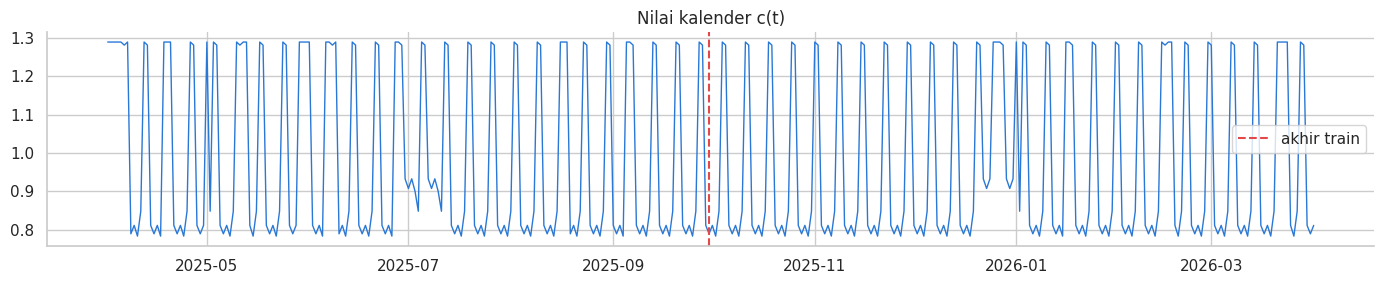

In [18]:
SCHOOL_BREAKS = [('2025-06-28', '2025-07-12'), ('2025-12-22', '2025-12-31')]
JABAR_BREAKS = [('2025-06-30', '2025-07-12'), ('2025-12-29', '2026-01-10')]
JABAR_CITIES = ['BOGOR', 'BEKASI', 'BANDUNG', 'DEPOK', 'CIKARANG', 'KARAWANG', 'CIREBON', 'GARUT', 'TASIKMALAYA',
                'SUMEDANG', 'CIANJUR', 'INDRAMAYU']
CUTI_BERSAMA = pd.to_datetime(['2025-04-02', '2025-04-03', '2025-04-04', '2025-04-07', '2025-05-13', '2025-05-30',
                               '2025-06-09', '2025-08-18', '2025-12-26', '2026-02-16', '2026-03-18', '2026-03-20',
                               '2026-03-23', '2026-03-24'])
RAMADAN = ('2026-02-19', '2026-03-20')


def calendar(hol, breaks=SCHOOL_BREAKS):
    c = hol.rename(columns={'date': 'date_show'})[['date_show', 'holiday_tipe']].copy()
    c['dow'] = c.date_show.dt.dayofweek
    c['is_hol'] = ((c.holiday_tipe == 'holiday') | c.date_show.isin(CUTI_BERSAMA)).astype(int)
    c['school'] = 0
    for a, b in breaks:
        c.loc[c.date_show.between(a, b), 'school'] = 1
    c['ramadan'] = c.date_show.between(*RAMADAN).astype(int)
    base = CFG.DOW_PROF[c.dow]
    base = np.where((c.school == 1) & (c.dow < 4), base * CFG.SCHOOL_WD, base)
    c['cal'] = np.where((c.is_hol == 1) & (c.ramadan == 0), np.maximum(base, CFG.HOL_LEVEL), base)
    return c.drop(columns='holiday_tipe').set_index('date_show')


CAL = calendar(hol)
CAL_JB = calendar(hol, JABAR_BREAKS)
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(CAL.index, CAL.cal, lw=1)
ax.axvline(CFG.TRAIN_END, color=PAL[7], ls='--', label='akhir train')
ax.set(title='Nilai kalender c(t)'); ax.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'cal_value.png'); plt.show()

## Fungsi Build Fitur

Kelompok fitur: (1) bentuk kurva pasangan D1 sampai D3, (2) agregat film nasional dan pangsa format, (3) kalender target dan riwayat, (4) jadwal rilis film lain, termasuk film baru yang dibuka di klaster yang sama pada tanggal target (terlihat di jendela D1 sampai D3 film tersebut), (5) ukuran klaster dan harga kota, (6) metadata film, (7) level relatif pasar (median film yang rilis 28 hari sebelumnya, gabungan jendela D1 sampai D3 train dan uji). Fitur level relatif v13 ditambahkan setelah `build` di sel berikutnya.

In [19]:
GENRES = ['Horror', 'Drama', 'Action', 'Comedy', 'Romance', 'Animation', 'Family', 'Thriller', 'Mystery']
RATING = {'Semua Umur': 0, 'Remaja': 1, 'Dewasa': 2, 'Dewasa 21': 3}


def film_table(vis):
    g = vis.groupby('movie_title')
    return pd.DataFrame({'d1': g.date_show.min(), 'occ': g.occupation_rate.mean(),
                         'tps': g.total_ticket.sum() / g.total_show.sum().clip(lower=1),
                         'logT': np.log1p(g.total_ticket.sum() / 3),
                         'lpc': np.log1p(g.total_ticket.sum() / 3 / g.cinema_ids.nunique().clip(lower=1))})


def make_ctx(visible, size_tx, market):
    rel = visible.assign(base=base_title(visible.movie_title)).groupby('base').agg(
        d1=('date_show', 'min'), tix=('total_ticket', 'sum')).reset_index()
    rel['tix'] /= 3
    cs = size_tx.groupby('cinema_ids').total_ticket.sum() / size_tx.groupby('cinema_ids').date_show.nunique()
    nf = size_tx.groupby(['cinema_ids', 'date_show']).movie_title.nunique().groupby('cinema_ids').mean()
    csh = size_tx.groupby(['cinema_ids', 'date_show']).total_show.sum().groupby('cinema_ids').median()
    return dict(releases=rel, market=market, visible=visible, cin_size=np.log10(cs), cin_nfilms=nf, cin_shows=csh)


def cinema_comp(X, vis, cin_shows):
    v = vis.assign(base=base_title(vis.movie_title))
    agg = v.groupby(['cinema_ids', 'date_show', 'base']).agg(sh=('total_show', 'sum'), tx=('total_ticket', 'sum')).reset_index()
    m = X[['cinema_ids', 'date_show']].assign(base=base_title(X.movie_title)).reset_index().merge(
        agg, on=['cinema_ids', 'date_show'], how='left', suffixes=('', '_o'))
    m = m[m.base != m.base_o]
    g = m.groupby('index').agg(c_new_n=('base_o', 'nunique'), c_new_sh=('sh', 'sum'), c_new_tx=('tx', 'sum'))
    X = X.join(g).fillna({'c_new_n': 0, 'c_new_sh': 0, 'c_new_tx': 0})
    X['c_new_sh_rel'] = X.c_new_sh / X.cinema_ids.map(cin_shows).fillna(X.c_new_sh.median() + 1)
    X['c_new_sh_vs_own'] = X.c_new_sh / X.sh3.clip(lower=1)
    X['c_new_tx_vs_own'] = np.log1p(X.c_new_tx) - np.log1p(X.y3)
    return X


def open_count(X, rel):
    d = np.sort(rel.d1.values.astype('datetime64[D]'))
    a = np.searchsorted(d, X.d1.values.astype('datetime64[D]'), side='right')
    b = np.searchsorted(d, X.date_show.values.astype('datetime64[D]'), side='right')
    return b - a


def build(hh, tgt, ctx):
    mv = movies.set_index('original_title')
    d1 = hh.groupby('movie_title').date_show.min().rename('d1')
    hh = hh.join(d1, on='movie_title')
    hh['d'] = (hh.date_show - hh.d1).dt.days + 1
    piv = lambda v, p: hh.pivot_table(index=KEY, columns='d', values=v, fill_value=0).reindex(columns=[1, 2, 3], fill_value=0).add_prefix(p)
    P = pd.concat([piv('total_ticket', 'y'), piv('total_show', 'sh')], axis=1)
    P['mean3'] = P[['y1', 'y2', 'y3']].mean(axis=1)
    P['scale'] = P.mean3.clip(lower=1)
    P['log_s'] = np.log1p(P.mean3)
    for i in (1, 2, 3):
        P[f'p{i}'] = P[f'y{i}'] / P.scale
    P['n_hist'] = (P[['y1', 'y2', 'y3']] > 0).sum(axis=1)
    P['sh_trend'] = P.sh3 / P[['sh1', 'sh2']].max(axis=1).clip(lower=1)
    P = P.reset_index()

    Fd = hh.groupby(['movie_title', 'd']).agg(T=('total_ticket', 'sum'), nc=('cinema_ids', 'nunique')).unstack().fillna(0)
    Fd.columns = [f'f{a}{b}' for a, b in Fd.columns]
    Fd = Fd.reindex(columns=[f'f{a}{b}' for a in ['T', 'nc'] for b in (1, 2, 3)], fill_value=0)
    Fm = Fd[['fT1', 'fT2', 'fT3']].mean(axis=1).clip(lower=1)
    for i in (1, 2, 3):
        Fd[f'fp{i}'] = Fd[f'fT{i}'] / Fm
    ncmax = Fd[['fnc1', 'fnc2', 'fnc3']].max(axis=1).clip(lower=1)
    Fd['f_logT'] = np.log1p(Fm)
    Fd['f_nc_trend'] = Fd.fnc3 / Fd.fnc1.clip(lower=1)
    Fd['f_occ'] = hh.groupby('movie_title').occupation_rate.mean()
    h3 = hh[hh.d == 3].groupby('movie_title')
    Fd['f_tps3'] = h3.total_ticket.sum() / h3.total_show.sum()
    Fd = Fd.join(d1)
    Fd['base'] = base_title(pd.Series(Fd.index, index=Fd.index))
    Fd['fmt'] = fmt(pd.Series(Fd.index, index=Fd.index)).map({'2D': 0, '3D': 1, 'IMAX 2D': 2, 'IMAX 3D': 3})
    bT = hh.assign(base=base_title(hh.movie_title)).groupby('base').total_ticket.sum() / 3
    Fd['fmt_share'] = np.log1p(Fm) - np.log1p(Fd.base.map(bT))
    Fd['d1_dow'] = Fd.d1.dt.dayofweek
    m = mv.reindex(Fd.base)
    Fd['rating'] = m.age_rating.map(RATING).values
    for g_ in GENRES:
        Fd[f'g_{g_}'] = m.genre.fillna('').str.contains(g_).astype(int).values
    Fd['n_genre'] = m.genre.fillna('').str.count(',').values + 1
    Fd['n_cast'] = m.casts.fillna('').str.count(',').values + 1
    rel = ctx['releases']
    Fd['comp_n'] = [((rel.base != r.base) & (rel.d1 > r.d1) & (rel.d1 <= r.d1 + pd.Timedelta(days=9))).sum() for _, r in Fd.iterrows()]
    Fd['f_share_cohort'] = np.log1p(Fd.base.map(bT)) - np.log1p(Fd.d1.map(rel.groupby('d1').tix.sum()))
    mk = ctx['market']
    win = lambda t: mk[(mk.d1 < t) & (mk.d1 >= t - pd.Timedelta(days=28))]
    Fd[['mk_occ', 'mk_tps', 'mk_logT', 'mk_lpc']] = [win(t)[['occ', 'tps', 'logT', 'lpc']].median().tolist() for t in Fd.d1]
    Fd['occ_rel'] = Fd.f_occ / Fd.mk_occ
    Fd['tps_rel'] = Fd.f_tps3 / Fd.mk_tps
    Fd['logT_rel'] = Fd.f_logT - Fd.mk_logT
    Fd['film_pc_vs_mkt'] = np.log1p(Fm / ncmax) - Fd.mk_lpc

    X = tgt.merge(P, on=KEY, how='left').merge(Fd.drop(columns=['base']), left_on='movie_title', right_index=True, how='left')
    X['h'] = (X.date_show - X.d1).dt.days + 1
    jb = (X.city_name.isin(JABAR_CITIES) & CFG.REGIONAL_CAL).values
    cal_at = lambda dates, col: np.where(jb, CAL_JB[col].reindex(dates).values, CAL[col].reindex(dates).values)
    X['dow'] = X.date_show.dt.dayofweek.values
    X['t_hol'], X['t_school'], X['t_ramadan'] = cal_at(X.date_show, 'is_hol'), cal_at(X.date_show, 'school'), cal_at(X.date_show, 'ramadan')
    ch = np.stack([cal_at(X.d1 + pd.Timedelta(days=k), 'cal') for k in range(3)], 1)
    X['cal_mult'] = cal_at(X.date_show, 'cal') / ch.mean(1)
    X['hol_in_hist'] = np.stack([cal_at(X.d1 + pd.Timedelta(days=k), 'is_hol') for k in range(3)], 1).sum(1)
    # D1-D3 tickets divided by the calendar value of their own day; labels and the MASE scale are untouched
    q = np.stack([X[f'y{i}'].values / cal_at(X.d1 + pd.Timedelta(days=i - 1), 'cal') for i in (1, 2, 3)], 1)
    for i in (1, 2, 3):
        X[f'cal_p{i}'] = q[:, i - 1] / np.maximum(q.mean(1), 1)
    X['cal_log31'] = np.log1p(q[:, 2]) - np.log1p(q[:, 0])
    X['n_comp_open'] = open_count(X, rel)
    X = cinema_comp(X, ctx['visible'], ctx['cin_shows'])
    X['share'] = X.log_s - np.log1p(X[['fT1', 'fT2', 'fT3']].mean(axis=1) / X.fnc3.clip(lower=1))
    X['pair_vs_mkt'] = X.log_s - X.mk_lpc
    X['p3_rel'] = X.p3 - X.fp3
    X['p1_rel'] = X.p1 - X.fp1
    X['cin_size'] = X.cinema_ids.map(ctx['cin_size'])
    X['cin_nfilms'] = X.cinema_ids.map(ctx['cin_nfilms'])
    X['cin_new'] = X.cin_size.isna().astype(int)
    pr = price.pivot(index='city_name', columns='price_day', values='ceil')
    X['price_wkd'] = X.city_name.map(pr.Weekday)
    X['price_prem'] = X.city_name.map(pr.Weekend / pr.Weekday)
    return X

Fitur dibangun untuk film rilis luas, film rilis terbatas (hanya latih), dan data uji. Tiga pemeriksaan wajib: jumlah baris tetap, urutan `id` uji tetap, dan skala sama persis dengan fungsi `hitung_skala` resmi.

In [20]:
market = pd.concat([film_table(vis_tr), film_table(hist)])
ctx_tr = make_ctx(vis_tr, train, market)
Xtr = build(hs, ts, ctx_tr)
Xlim = build(hl, tl, ctx_tr)
Xte = build(hist, test, make_ctx(hist, train, market))

assert len(Xtr) == len(ts) and len(Xte) == len(test) and (Xte.id.values == test.id.values).all()
ref = Xte.join(pair_scale(hist), on=KEY, rsuffix='_ref')
assert np.allclose(ref.scale, ref.scale_ref)

BASE_FEATS = ['log_s', 'p1', 'p2', 'p3', 'n_hist', 'sh_trend', 'fnc1', 'fnc2', 'fnc3', 'fp1', 'fp2', 'fp3', 'f_logT',
              'f_nc_trend', 'fmt', 'fmt_share', 'd1_dow', 'rating'] + [f'g_{g_}' for g_ in GENRES] + [
              'n_genre', 'n_cast', 'comp_n', 'f_share_cohort', 'h', 'dow', 't_hol', 't_school', 't_ramadan', 'cal_mult',
              'hol_in_hist', 'n_comp_open', 'share', 'p3_rel', 'p1_rel', 'cin_size', 'cin_nfilms', 'cin_new',
              'price_wkd', 'price_prem']
COMP_FEATS = ['c_new_n', 'c_new_sh', 'c_new_sh_rel', 'c_new_sh_vs_own', 'c_new_tx_vs_own']
CAL_FEATS = ['cal_p1', 'cal_p2', 'cal_p3', 'cal_log31']
FEATS = BASE_FEATS
ZFEATS = FEATS + COMP_FEATS
jb_changed = Xte.t_school.values != CAL.school.reindex(Xte.date_show).values
print(f'West Java calendar: {jb_changed.sum()} test rows change school flag ({jb_changed.mean():.2%}); train rows changed: '
      f'{int((Xtr.t_school.values != CAL.school.reindex(Xtr.date_show).values).sum())}')
for X_ in (Xtr, Xlim, Xte):
    assert np.isfinite(X_[CAL_FEATS].values).all()
print('calendar-normalised inputs (median train | test):', {c: (round(float(Xtr[c].median()), 3), round(float(Xte[c].median()), 3)) for c in CAL_FEATS})
print(f'train {len(Xtr)} rows | limited extra {len(Xlim)} | test {len(Xte)} | features {len(FEATS)}')
display(pd.DataFrame({'train_median': Xtr[['log_s', 'f_logT', 'pair_vs_mkt', 'film_pc_vs_mkt', 'share']].median(),
                      'test_median': Xte[['log_s', 'f_logT', 'pair_vs_mkt', 'film_pc_vs_mkt', 'share']].median()}).round(3))

West Java calendar: 1134 test rows change school flag (1.56%); train rows changed: 202
calendar-normalised inputs (median train | test): {'cal_p1': (1.221, 1.213), 'cal_p2': (0.96, 0.944), 'cal_p3': (0.797, 0.814), 'cal_log31': (-0.423, -0.392)}
train 56372 rows | limited extra 1435 | test 72611 | features 47


,train_median,test_median
log_s,5.204,4.529
f_logT,9.974,9.450
pair_vs_mkt,0.019,-0.123
film_pc_vs_mkt,0.353,0.286
share,-0.379,-0.435


## Fitur Level Relatif

Tiga fitur menggantikan dua fitur level absolut. `rel_nat` = log skala pasangan dikurangi log median skala pasangan film lain yang D1-nya berjarak paling jauh 14 hari; `rel_clu` = sama, tetapi hanya pasangan di klaster yang sama (minimal dua pembanding, selain itu memakai `rel_nat`); `f_rel` = log rata-rata tiket harian film dikurangi log median film lain pada jendela yang sama. Film pembanding tidak pernah judul dasar yang sama, sehingga versi IMAX atau 3D tidak menjadi pembandingnya sendiri. Referensi hanya memakai D1 sampai D3 film lain, bukan label D4 sampai D10, sehingga tidak ada kebocoran target, dan aturan informasi yang sama berlaku untuk train dan uji. Implementasinya diverifikasi dengan perhitungan brute-force pada sampel baris.

brute-force check of the cluster reference passed (80 rows); fallback to national reference: {'train': 0.0006, 'limited': 0.0, 'test': 0.001}


,train_median,test_median,shift,ks
feature,,,,
log_s,5.204,4.529,-0.675,0.231
f_logT,9.974,9.450,-0.524,0.236
rel_nat,0.307,0.229,-0.078,0.042
rel_clu,0.286,0.199,-0.087,0.043
f_rel,0.677,0.501,-0.176,0.105


cluster reference median (tickets/day): train 141 | test 77


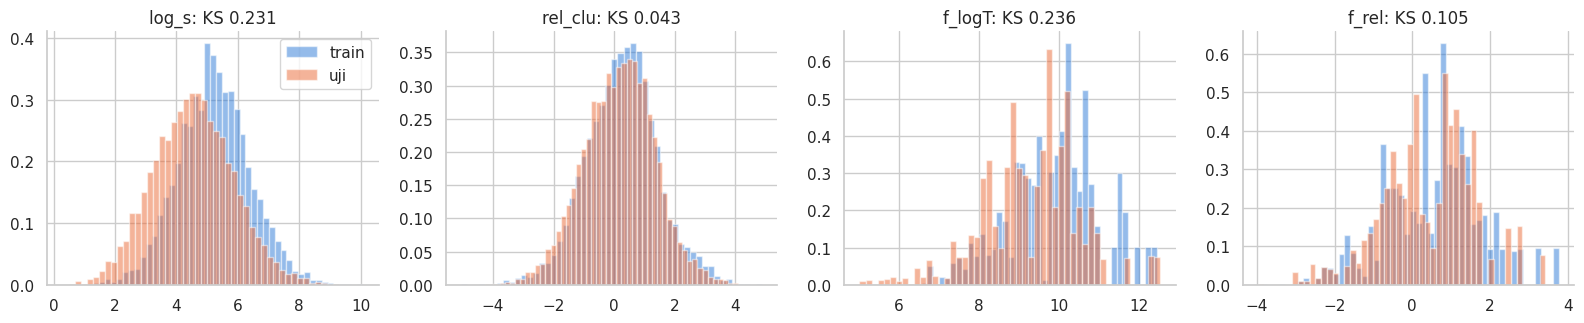

In [21]:
REL_FEATS = ['rel_nat', 'rel_clu', 'f_rel']
ABS_LEVEL = ['log_s', 'f_logT']


def add_relative(X, vp, vf):
    X = X.copy()
    X['ref_clu'], X['ref_nat'] = ref_cluster(X, 'sc', vp), ref_national(X, vp, 'sc')
    ls = np.log(X.scale.values)
    X['rel_nat'] = ls - np.log(np.clip(X.ref_nat.values, 1, None))
    X['rel_clu'] = np.where(np.isfinite(X.ref_clu), ls - np.log(np.clip(X.ref_clu.values, 1, None)), X.rel_nat)
    fm = X[['fT1', 'fT2', 'fT3']].mean(axis=1).clip(lower=1).values
    X['f_rel'] = np.log(fm) - np.log(np.clip(ref_national(X, vf, 'ft'), 1, None))
    return X


Xtr, Xlim, Xte = add_relative(Xtr, VP, VF), add_relative(Xlim, VP, VF), add_relative(Xte, VP, VF)
assert len(Xte) == len(test) and (Xte.id.values == test.id.values).all()
assert all(np.isfinite(X_[REL_FEATS].values).all() for X_ in (Xtr, Xlim, Xte))
FEATS_ABS = BASE_FEATS
FEATS_REL = [f for f in BASE_FEATS if f not in ABS_LEVEL] + REL_FEATS

rng_ = np.random.default_rng(CFG.SEED)
for X_ in (Xtr, Xte):
    for i in rng_.choice(len(X_), 40, replace=False):
        r_ = X_.iloc[i]
        k = (VP.cinema_ids == r_.cinema_ids) & ((VP.d1 - r_.d1).dt.days.abs() <= CFG.REL_WIN) & (VP.base != base_title(pd.Series([r_.movie_title]))[0])
        ref_bf = VP.sc[k].median() if k.sum() >= 2 else np.nan
        assert np.isclose(ref_bf, r_.ref_clu, equal_nan=True), (r_.movie_title, r_.cinema_ids)
print('brute-force check of the cluster reference passed (80 rows); fallback to national reference:',
      {n: round(float(np.isnan(X_.ref_clu).mean()), 4) for n, X_ in [('train', Xtr), ('limited', Xlim), ('test', Xte)]})

kt = pd.DataFrame([dict(feature=c, train_median=Xtr[c].median(), test_median=Xte[c].median(),
                        shift=Xte[c].median() - Xtr[c].median(), ks=ks_2samp(Xtr[c], Xte[c]).statistic)
                   for c in ABS_LEVEL + REL_FEATS]).set_index('feature')
display(kt.round(3))
print(f'cluster reference median (tickets/day): train {np.nanmedian(Xtr.ref_clu):.0f} | test {np.nanmedian(Xte.ref_clu):.0f}')
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
for a_, c in zip(ax, ['log_s', 'rel_clu', 'f_logT', 'f_rel']):
    a_.hist(Xtr[c], bins=50, density=True, alpha=.5, label='train'); a_.hist(Xte[c], bins=50, density=True, alpha=.5, label='uji')
    a_.set(title=f"{c}: KS {kt.loc[c, 'ks']:.3f}")
ax[0].legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'relative_features.png'); plt.show()

#### Insights

> Pasar uji sekitar separuh pasar train (median referensi klaster lokal 75 vs 146 tiket per hari). `log_s` dan `f_logT` bergeser sekitar -0,5 sampai -0,7 dengan jarak KS sekitar 0,23, sedangkan `rel_nat` dan `rel_clu` hampir identik di kedua periode (KS sekitar 0,04) dan `f_rel` turun ke sekitar 0,1. Level relatif mempertahankan informasi "pasangan ini lemah atau kuat" tanpa ikut membawa level pasar yang berubah.

> Di dalam train kedua jenis level saling berkorelasi, sehingga grouped CV hampir tidak bisa membedakannya. Tabel lookup lokal (`eda/69`) memperlihatkan bedanya baru muncul di luar distribusi train: dengan level absolut, porsi nol yang tersirat untuk baris uji 0,42 dan median $r$ 0,30, sedangkan dengan level relatif 0,30 dan 0,38.

## Verifikasi Drift: Adversarial Validation

Classifier dilatih membedakan baris simulasi dari baris uji dengan fold dikelompokkan per film (split acak memberi AUC palsu 1,0 karena fitur level film konstan dalam satu film).

In [22]:
def adv_auc(cols):
    A = pd.concat([Xtr[cols].assign(t=0, g=Xtr.movie_title), Xte[cols].assign(t=1, g=Xte.movie_title)], ignore_index=True)
    oof = np.zeros(len(A))
    for a, b in StratifiedGroupKFold(5, shuffle=True, random_state=CFG.SEED).split(A, A.t, A.g):
        m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=CFG.SEED, verbose=-1)
        oof[b] = m.fit(A.iloc[a][cols], A.t.iloc[a]).predict_proba(A.iloc[b][cols])[:, 1]
    return roc_auc_score(A.t, oof)


shape_cols = ['p1', 'p2', 'p3', 'fp1', 'fp3', 'share', 'sh_trend', 'd1_dow', 'n_hist']
print(f"AUC shape features only:         {adv_auc(shape_cols):.3f}")
print(f"AUC + absolute level (log_s, f_logT): {adv_auc(shape_cols + ['log_s', 'f_logT']):.3f}")
print(f"AUC + market-relative level:     {adv_auc(shape_cols + ['pair_vs_mkt', 'film_pc_vs_mkt']):.3f}")
print(f"AUC + v13 relative level:        {adv_auc(shape_cols + REL_FEATS):.3f}")
print(f"AUC full feature set, absolute:  {adv_auc(FEATS_ABS):.3f}")
print(f"AUC full feature set, relative:  {adv_auc(FEATS_REL):.3f}")

AUC shape features only:         0.510
AUC + absolute level (log_s, f_logT): 0.544
AUC + market-relative level:     0.479
AUC + v13 relative level:        0.467
AUC full feature set, absolute:  0.733
AUC full feature set, relative:  0.649


#### Insights

> Fitur bentuk kurva tidak bisa membedakan train dan uji (AUC sekitar 0,51). Level absolut menaikkan AUC karena pasar uji lebih sepi, sedangkan level relatif tidak. Pada set fitur lengkap, sisa AUC berasal dari fitur lain yang memang berbeda antarperiode (kalender, jadwal rilis, cakupan klaster), bukan dari level pasangan. Penurunan AUC set lengkap dari absolut ke relatif menunjukkan seberapa besar pergeseran yang dihapus oleh penggantian dua fitur level.

## Dunia Thinned untuk Data Latih dan Validasi

Setiap dunia thinned dibangun dengan fungsi yang sama dengan sampel mentah: transaksi yang sudah ditipiskan (Bagian 6), D1 dari data mentah, simulasi aturan panitia, `build`, lalu level relatif terhadap film lain **di dunia yang sama**. Aturan informasi meniru data uji: statistik histori klaster (`cin_size`, `cin_nfilms`, jumlah show) dihitung dari train mentah, karena bagi film uji train adalah masa lalu yang ramai, sedangkan jendela D1 sampai D3 dan referensi pasar berasal dari dunia yang sepi. Tiga dunia ($\pi$ 0,35, 0,5, 0,7) menjadi data latih tambahan; satu dunia dengan seed terpisah ($\pi$ 0,45) menjadi data validasi. Pemeriksaan: jarak KS setiap fitur ke data uji (mentah vs thinned) dan porsi nol serta median $r$ per bucket skala.

worlds built in 8s | rows: raw 56372, pi 0.35: 56169, pi 0.5: 56232, pi 0.7: 56344, validation world: 56267


,raw vs test,validation world vs test,median raw,median validation world,median test
log_s,0.231,0.063,5.204,4.415,4.529
f_logT,0.236,0.170,9.974,9.174,9.450
f_occ,0.409,0.214,24.069,10.809,12.836
f_tps3,0.387,0.313,36.883,16.656,20.854
p1,0.060,0.054,1.063,1.060,1.082
p2,0.083,0.074,0.953,0.948,0.914
p3,0.049,0.042,0.937,0.934,0.950
sh_trend,0.091,0.092,1.000,1.000,0.833
share,0.039,0.039,-0.379,-0.375,-0.435
rel_clu,0.043,0.036,0.286,0.280,0.199


,raw,validation world,test,zero rate raw,zero rate validation world,zero rate pi 0.35,zero rate pi 0.5,zero rate pi 0.7
scale,,,,,,,,
"(0.0, 5.0]",0.003,0.013,0.015,0.758,0.762,0.775,0.760,0.714
"(5.0, 20.0]",0.029,0.103,0.114,0.761,0.660,0.632,0.678,0.725
"(20.0, 50.0]",0.101,0.217,0.198,0.622,0.509,0.455,0.530,0.585
"(50.0, 100.0]",0.169,0.241,0.200,0.520,0.302,0.246,0.333,0.430
"(100.0, 200.0]",0.235,0.210,0.195,0.333,0.153,0.104,0.169,0.245
"(200.0, 500.0]",0.276,0.149,0.178,0.151,0.040,0.029,0.050,0.093
"(500.0, 1000000000.0]",0.188,0.067,0.100,0.026,0.008,0.005,0.010,0.016


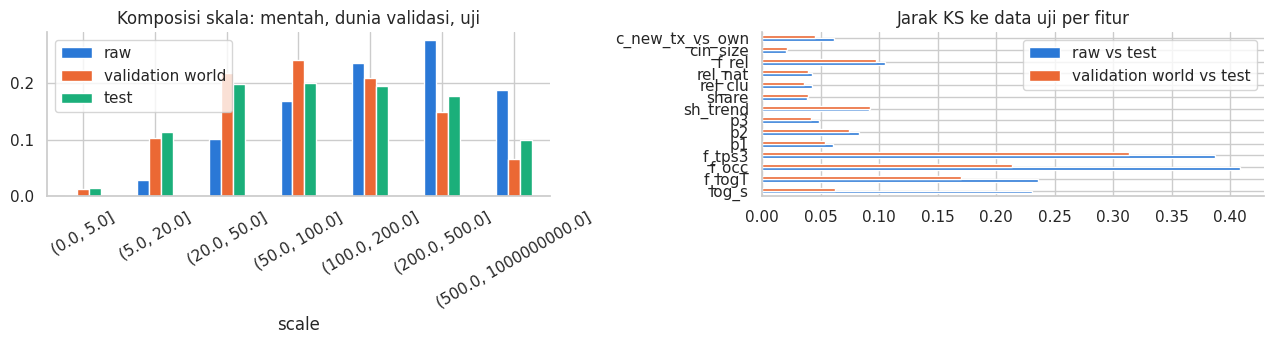

In [23]:
def build_world(tx, tag):
    vis_w = visible_windows(tx, D_wide)
    mk_w = pd.concat([film_table(vis_w), film_table(hist)])
    hs_w, ts_w = simulate(tx, D_wide.drop(running, errors='ignore'))
    Xw = build(hs_w, ts_w, make_ctx(vis_w, train, mk_w))
    Xw = add_relative(Xw, *make_pools(pd.concat([vis_w, hist], ignore_index=True)))
    return Xw.assign(world=tag)


t0 = time.time()
Xtr['world'], Xlim['world'], Xte['world'] = 'raw', 'raw', 'test'
THIN = {pi: build_world(tx_, f'pi{pi}') for pi, tx_ in TX_T.items()}
XQ = build_world(TX_Q, f'val{CFG.VAL_PI}')
for X_ in list(THIN.values()) + [XQ]:
    assert set(base_title(X_.movie_title)) <= set(base_title(Xtr.movie_title))
    assert np.isfinite(X_[REL_FEATS].values).all()
print(f'worlds built in {time.time() - t0:.0f}s | rows: raw {len(Xtr)}, ' + ', '.join(f'pi {p_}: {len(X_)}' for p_, X_ in THIN.items())
      + f', validation world: {len(XQ)}')

chk = ['log_s', 'f_logT', 'f_occ', 'f_tps3', 'p1', 'p2', 'p3', 'sh_trend', 'share', 'rel_clu', 'rel_nat', 'f_rel', 'cin_size', 'c_new_tx_vs_own']
KS = pd.DataFrame({'raw vs test': [ks_2samp(Xtr[c].dropna(), Xte[c].dropna()).statistic for c in chk],
                   'validation world vs test': [ks_2samp(XQ[c].dropna(), Xte[c].dropna()).statistic for c in chk],
                   'median raw': [Xtr[c].median() for c in chk], 'median validation world': [XQ[c].median() for c in chk],
                   'median test': [Xte[c].median() for c in chk]}, index=chk)
display(KS.round(3))
SB = [0, 5, 20, 50, 100, 200, 500, 1e9]
comp_ = pd.DataFrame({n: pd.cut(X_.scale, SB).value_counts(normalize=True).sort_index() for n, X_ in
                      [('raw', Xtr), ('validation world', XQ), ('test', Xte)]})
for n, X_ in [('raw', Xtr), ('validation world', XQ)] + [(f'pi {p_}', X_) for p_, X_ in THIN.items()]:
    g = X_.groupby(pd.cut(X_.scale, SB), observed=False)
    comp_[f'zero rate {n}'] = g.total_ticket.apply(lambda v: (v == 0).mean())
display(comp_.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
comp_[['raw', 'validation world', 'test']].plot.bar(ax=ax[0], rot=30); ax[0].set(title='Komposisi skala: mentah, dunia validasi, uji')
KS[['raw vs test', 'validation world vs test']].plot.barh(ax=ax[1]); ax[1].set(title='Jarak KS ke data uji per fitur')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'thinned_worlds.png'); plt.show()

#### Insights

> Analisis lokal (`eda/88`, `eda/89`) memberi gambaran yang diharapkan di sini. Dunia thinned 0,4 memiliki porsi skala 5 sampai 20 sebesar 0,118 (uji 0,114, mentah 0,029) dan skala di bawah 5 sebesar 0,015 (uji 0,015), tanpa bobot apa pun. Jarak KS `log_s` ke uji turun dari 0,23 ke 0,09, okupansi dari 0,32 ke 0,17. Fitur kalender, jadwal, dan cakupan tidak berubah karena memang tidak disentuh thinning. Porsi nol D4 sampai D10 pada bucket 50 sampai 200 turun dari sekitar 0,41 ke 0,21: pasangan kecil di dunia thinned adalah pasangan sehat yang kecil, persis seperti pasangan kecil di data uji.

> **Duplikasi dan kebocoran.** Setiap dunia adalah salinan yang sangat mirip dari film yang sama. Karena itu fold ditentukan per judul dasar untuk semua dunia sekaligus: film validasi tidak pernah muncul di dunia mana pun di bagian latih. Pada backtest temporal, salinan dunia mengikuti aturan cutoff yang sama dengan film aslinya.

---

# Modeling <a name="8"></a>

---

Bagian ini mempertahankan disiplin v10 sampai v13: aturan adopsi ditulis sebelum hasil terlihat, satu perubahan per langkah, dan model dibandingkan pada fitur yang dibekukan. Urutannya: (1) keputusan **data latih mentah vs mentah + dunia thinned** dengan LightGBM sebagai kontrol, dalam dua varian (T1 fitur v13, T2 ditambah fitur level relatif); (2) kandidat model pada konfigurasi terpilih: TabPFN-3.5 Fast FP16 dan TabM; (3) koreksi pencopotan per model; (4) blend dengan batas bobot 200 MB. Lensa: (1) **dunia validasi thinned** ($\pi$ 0,45, MASE biasa tanpa bobot karena komposisinya sudah mirip uji), lensa utama; (2) **grouped CV mentah** dengan bobot komposisi uji (TW), pembatas; (3) **backtest temporal** Juli, Agustus, September, pembatas; (4) **proxy periode uji** (D1, D2 ke D3), satu-satunya label di dalam periode uji, untuk menilai apakah augmentasi memperbaiki prediksi di periode uji.

## Ringkasan Analisis 8 Oktober

| Analisis | Angka | Konsekuensi di v14 |
| :--- | :--- | :--- |
| `eda/79` Anatomi galat v13 | Late starter 1,8% bobot, 16% galat; 1% baris teratas membawa 29% galat; galat terbesar di D4 sampai D5 rilis Rabu | Fokus ke struktur, bukan ekor |
| `eda/80` Late starter | 88% bertahan di D4; median r aktual 1,53 vs prediksi 1,40; aturan y3 x kalender lebih buruk | Tidak ada perlakuan khusus |
| `eda/81`, `eda/82` Inferensi dari skor public yang sudah ada | Dengan kalibrasi OOF v13 per sel, MASE harapan baris non-Lebaran 0,386 sampai 0,397 (public 0,40 sampai 0,41, galat Lebaran tersirat 0,64); level label uji jauh di atas kalibrasi (m >= 1,2) mustahil | Offset adalah komposisi, bukan bias level |
| `eda/83` Guncangan klaster x tanggal (label film lain, leave-one-film-out) | TW memburuk 0,327 ke 0,355; korelasi +0,017 | Oracle 0,202 di `eda/37` adalah artefak; jalan ditutup |
| `eda/84` Level residual (leave-one-out jujur) | Film x tanggal: korelasi 0,57, batas -0,046; klaster: 0 | Informasi yang hilang adalah lintasan film setelah D3 |
| `eda/85` Tekanan kompetisi per tanggal | Korelasi dengan residual film x tanggal di bawah 0,05 | Tidak dipakai |
| `eda/86` Amplitudo akhir pekan per klaster | Reliabilitas split-half 0,91; residual akhir pekan rilis Rabu naik monoton per kuintil (-0,26 ke -0,06) | Sinyal nyata tetapi kecil (-0,0007); dicatat |
| `eda/87`, `eda/88`, `eda/89`, `eda/90` Binomial thinning | Mereproduksi label periode uji, komposisi uji, dan 75% pergeseran pencopotan; lookup di dunia thinned 0,380 (dilatih mentah) vs 0,355 (dilatih thinned) | **Perubahan utama v14** |

Angka di atas berasal dari tabel lookup lokal tanpa model; besarnya efek pada model diukur di bawah.

## Lensa Validasi

Fold dikelompokkan per judul dasar film, dan peta fold yang sama dipakai untuk setiap dunia. Bobot `TW` menyamakan porsi setiap sel (bucket skala x hari pertama laku) dengan data uji pada sampel mentah. Dunia validasi thinned dinilai dengan MASE biasa (`QW`) dan juga dengan bobot sel yang sama (`QW_TW`) sebagai pembanding.

In [24]:
groups = base_title(Xtr.movie_title).values
ug = np.array(sorted(set(groups)))
fold_of = dict(zip(ug, np.random.RandomState(CFG.SEED).permutation(len(ug)) % CFG.N_FOLDS))
FOLD = np.array([fold_of[g_] for g_ in groups])
fold_any = lambda X: np.array([fold_of.get(b_, -1) for b_ in base_title(X.movie_title)])
FOLD_Q = fold_any(XQ)
assert (FOLD_Q >= 0).all()
y, s, cm, hh_ = Xtr.total_ticket.values, Xtr.scale.values, Xtr.cal_mult.values, Xtr.h.values
yq, sq, cmq = XQ.total_ticket.values, XQ.scale.values, XQ.cal_mult.values

fday = lambda D: pd.Series(np.where(D.y1 > 0, 1, np.where(D.y2 > 0, 2, 3)), index=D.index)
cell = lambda D: pd.cut(D.scale, CFG.TW_BINS).astype(str) + '|' + fday(D).astype(str)
test_share = cell(Xte).value_counts(normalize=True)
tw_of = lambda D: (lambda w_: w_ / w_.mean())(cell(D).map(test_share / cell(D).value_counts(normalize=True)).fillna(0).astype(float).values)
TW, TWQ = tw_of(Xtr), tw_of(XQ)
print(f'validation world: {len(XQ)} rows, zero share {np.mean(yq == 0):.3f} (raw {np.mean(y == 0):.3f}); '
      f'effective sample of TW on the validation world {TWQ.sum() ** 2 / (TWQ ** 2).sum():.0f} of {len(TWQ)} (raw {TW.sum() ** 2 / (TW ** 2).sum():.0f})')


def score(p, name):
    e = np.abs(y - p) / s
    r = dict(model=name, MASE=e.mean(), TW_MASE=np.average(e, weights=TW), small=e[s <= 20].mean(), big=e[s > 200].mean())
    print(f"{name:40s} MASE {r['MASE']:.4f} | TW-MASE {r['TW_MASE']:.4f} | s<=20 {r['small']:.4f} | s>200 {r['big']:.4f}")
    return r


results = []
rc = y / s / cm
oof_base, oofq_base = np.zeros(len(Xtr)), np.zeros(len(XQ))
for k in range(CFG.N_FOLDS):
    a, b, bq = FOLD != k, FOLD == k, FOLD_Q == k
    med = pd.Series(rc[a]).groupby([hh_[a], Xtr.d1_dow.values[a]]).median()
    oof_base[b] = med.reindex(pd.MultiIndex.from_arrays([hh_[b], Xtr.d1_dow.values[b]])).fillna(np.median(rc[a])).values * cm[b] * s[b]
    oofq_base[bq] = med.reindex(pd.MultiIndex.from_arrays([XQ.h.values[bq], XQ.d1_dow.values[bq]])).fillna(np.median(rc[a])).values * cmq[bq] * sq[bq]
results.append(score(oof_base, 'median r/c by (h, D1 dow)'))
print(f'same baseline on the validation world: QW {np.mean(np.abs(yq - oofq_base) / sq):.4f}')

validation world: 56267 rows, zero share 0.300 (raw 0.300); effective sample of TW on the validation world 43479 of 56267 (raw 35094)
median r/c by (h, D1 dow)                MASE 0.4002 | TW-MASE 0.4330 | s<=20 0.9822 | s>200 0.3279
same baseline on the validation world: QW 0.4059


## Proxy Periode Uji: Apakah Augmentasi Memperbaiki Prediksi di Periode Uji?

Tugas proxy Bagian 6 (D3 dari D1 dan D2) dilatih dua kali: hanya pada proxy train mentah, dan pada proxy mentah + proxy dari tiga dunia thinned. Keduanya dinilai pada pasangan periode uji. Dua set fitur diuji: level absolut seperti v4 sampai v13, dan absolut + relatif. Keluarannya MAE level D3 di periode uji (lensa periode uji untuk keputusan augmentasi) dan offset pencopotan $a$ yang dipakai koreksi $\lambda a$ untuk konfigurasi yang bersesuaian.

test_period_mae  test_period_bias  mae_scale_5_50  \
raw      abs            0.4759            0.0550          0.6073   
         both           0.4697            0.0550          0.6008   
raw+thin abs            0.4813            0.0029          0.6200   
         both           0.4811            0.0005          0.6182   

               bias_scale_5_50  stop_logloss_unshifted  pull_a  
raw      abs            0.0896                  0.2522   -1.32  
         both           0.0634                  0.2357   -1.23  
raw+thin abs            0.0000                  0.2245   -0.75  
         both          -0.0000                  0.2069   -0.59

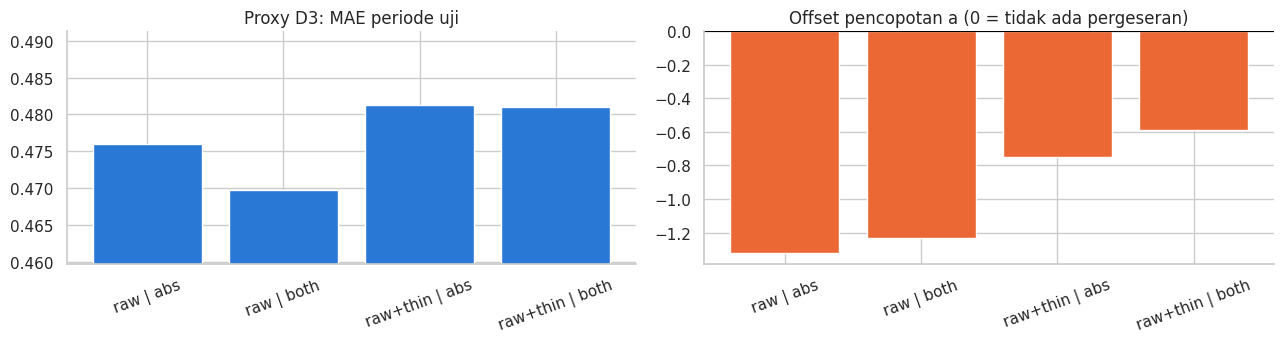

In [25]:
pools_raw = (VP, VF)
pools_w = {pi: make_pools(pd.concat([visible_windows(tx_, D_wide), hist], ignore_index=True)) for pi, tx_ in TX_T.items()}


def proxy_rel(Pp, vp, vf):
    Pp = Pp.copy()
    c3 = np.stack([CAL.cal.reindex(Pp.d1 + pd.Timedelta(days=k)).values for k in range(3)], 1)
    Pp['cm'] = c3[:, 2] / c3[:, :2].mean(1)
    rc_, rn_ = ref_cluster(Pp, 'sc', vp), ref_national(Pp, vp, 'sc')
    Pp['rel_nat'] = np.log(Pp.s) - np.log(np.clip(rn_, 1, None))
    Pp['rel_clu'] = np.where(np.isfinite(rc_), np.log(Pp.s) - np.log(np.clip(rc_, 1, None)), Pp.rel_nat)
    Pp['f_rel'] = Pp.f_log - np.log1p(ref_national(Pp, vf, 'ft'))
    return Pp


PA2, PB2 = proxy_rel(PA, *pools_raw), proxy_rel(PB, *pools_raw)
PAT2 = pd.concat([proxy_rel(PA_T[PA_T.world == pi], *pools_w[pi]) for pi in CFG.THIN_PIS], ignore_index=True)
PCOLS = {'abs': ['q1', 'q2', 'log_s', 'sh1', 'sh2', 'sh_tr', 'occ2', 'f_tr', 'f_log', 'f_nc', 'cm', 'd1_dow']}
PCOLS['both'] = PCOLS['abs'] + ['rel_nat', 'rel_clu', 'f_rel']
zB, rB = (PB2.y == 0).values, (PB2.y / PB2.s).values
mid = PB2.s.between(5, 50).values
PULL, PROXY = {}, {}
for data_name, PTR in [('raw', PA2), ('raw+thin', pd.concat([PA2, PAT2], ignore_index=True))]:
    for lv, cols in PCOLS.items():
        clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=100, verbose=-1,
                                 deterministic=True, force_row_wise=True, random_state=CFG.SEED).fit(PTR[cols], PTR.y == 0)
        pB0 = np.clip(clf.predict_proba(PB2[cols])[:, 1], 1e-4, 1 - 1e-4)
        a_ = float(grid_a[np.argmin([nll(pB0, zB, a) for a in grid_a])])
        pB_ = np.clip(lgb.LGBMRegressor(**pm, random_state=CFG.SEED).fit(PTR[cols], PTR.y / PTR.s).predict(PB2[cols]), 0, None)
        PULL[(data_name, lv)] = a_
        PROXY[(data_name, lv)] = dict(test_period_mae=np.mean(np.abs(rB - pB_)), test_period_bias=np.median(rB - pB_),
                                      mae_scale_5_50=np.mean(np.abs(rB - pB_)[mid]), bias_scale_5_50=np.median((rB - pB_)[mid]),
                                      stop_logloss_unshifted=nll(pB0, zB, 0.0), pull_a=a_)
PROXY = pd.DataFrame(PROXY).T
display(PROXY.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
lab_ = [f'{a_} | {b_}' for a_, b_ in PROXY.index]
ax[0].bar(lab_, PROXY.test_period_mae, color=PAL[0]); ax[0].set(title='Proxy D3: MAE periode uji', ylim=(PROXY.test_period_mae.min() - .01, PROXY.test_period_mae.max() + .01))
ax[1].bar(lab_, PROXY.pull_a, color=PAL[1]); ax[1].axhline(0, color='k', lw=.8); ax[1].set(title='Offset pencopotan a (0 = tidak ada pergeseran)')
for a_ in ax:
    a_.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'proxy_thinning.png'); plt.show()

#### Insights

> Lookup lokal memprediksi arah berikut: model yang dilatih dengan proxy dunia thinned lebih baik di periode uji (lookup: MAE 0,3505 ke 0,3346), dan offset pencopotan $a$ menyusut jauh mendekati nol (lookup absolut: -1,33 ke -0,54 untuk mentah + thinned). Tabel di atas mengulang uji itu dengan LightGBM. Bila $a$ untuk konfigurasi thinned tinggal kecil, koreksi $\lambda a$ hampir tidak mengubah prediksi; pergeseran itu kini sudah ada di data latih, bukan ditebak lewat satu parameter.

## Statistik Klaster Fold-Local

Statistik klaster (ukuran, jumlah film per hari, jumlah show) dihitung ulang per fold tanpa seluruh transaksi film fold validasi, dan per cutoff temporal hanya dari transaksi sebelum cutoff. Statistik ini selalu berasal dari train mentah, juga untuk dunia thinned, karena bagi data uji train adalah masa lalu yang ramai.

In [26]:
def cin_stats(tx):
    cs = tx.groupby('cinema_ids').total_ticket.sum() / tx.groupby('cinema_ids').date_show.nunique()
    nf = tx.groupby(['cinema_ids', 'date_show']).movie_title.nunique().groupby('cinema_ids').mean()
    csh = tx.groupby(['cinema_ids', 'date_show']).total_show.sum().groupby('cinema_ids').median()
    return np.log10(cs), nf, csh


def with_cin(X, stats):
    cs, nf, csh = stats
    X = X.copy()
    X['cin_size'] = X.cinema_ids.map(cs)
    X['cin_nfilms'] = X.cinema_ids.map(nf)
    X['cin_new'] = X.cin_size.isna().astype(int)
    X['c_new_sh_rel'] = X.c_new_sh / X.cinema_ids.map(csh).fillna(X.c_new_sh.median() + 1)
    return X


TRAIN_BASE = base_title(train.movie_title)
STATS_ALL = cin_stats(train)
assert np.allclose(with_cin(Xtr, STATS_ALL).cin_size.fillna(-9), Xtr.cin_size.fillna(-9))
STATS_FOLD = {k: cin_stats(train[~TRAIN_BASE.isin(set(groups[FOLD == k]))]) for k in range(CFG.N_FOLDS)}
rk = np.mean([pd.Series(with_cin(Xtr[FOLD == k], STATS_FOLD[k]).cin_size.values).corr(pd.Series(Xtr.cin_size[FOLD == k].values), method='spearman') for k in range(CFG.N_FOLDS)])
print(f'rank correlation of cin_size, global vs fold-local: {rk:.4f}')

rank correlation of cin_size, global vs fold-local: 0.9989


## Mesin Evaluasi

`training_set` menyusun bagian latih: sampel mentah, film rilis terbatas, dan bila konfigurasi memakai augmentasi, salinan dari setiap dunia thinned untuk film yang sama. `run_cv` melatih per fold lalu memprediksi baris mentah dan baris dunia validasi milik fold itu dengan model yang sama, sehingga lensa dunia validasi tidak butuh fit tambahan. `temporal` menjalankan backtest bulanan; salinan dunia ikut aturan cutoff film aslinya. LightGBM sama dengan v8 sampai v13 (L1 + hurdle, bobot hurdle 0,75), dengan 3 seed L1. Setiap komponen disimpan sebagai tiga prediksi: OOF mentah, temporal, dan OOF dunia validasi.

In [27]:
LGB_BASE = {k: v for k, v in CFG.LGB_PARAMS.items() if k not in ('objective', 'n_estimators')}
LGB_FAST = {**LGB_BASE, 'n_estimators': 300, 'learning_rate': 0.05}
MONTHS = ['2025-07', '2025-08', '2025-09']
FEATSETS = {'abs': FEATS_ABS, 'both': FEATS_ABS + REL_FEATS}


def r_target(Xa):
    return (Xa.total_ticket / Xa.scale / Xa.cal_mult).values


def fit_lgb_all(Xa, feats, zfeats):
    l1 = [lgb.LGBMRegressor(objective='l1', n_estimators=CFG.LGB_PARAMS['n_estimators'], **LGB_BASE, random_state=sd)
          .fit(Xa[feats], r_target(Xa), sample_weight=Xa.cal_mult.values) for sd in CFG.SEEDS]
    zc = lgb.LGBMClassifier(objective='binary', **{**LGB_FAST, 'num_leaves': 31}, random_state=CFG.SEED).fit(Xa[zfeats], Xa.total_ticket == 0)
    pos = Xa[Xa.total_ticket > 0]
    qm = [lgb.LGBMRegressor(objective='quantile', alpha=float(q), **LGB_FAST, random_state=CFG.SEED).fit(pos[feats], r_target(pos))
          for q in CFG.QS]
    return dict(l1=l1, zc=zc, qm=qm)


def lgb_size_mb(m):
    return sum(len(zlib.compress(x.booster_.model_to_string().encode(), 9)) for x in m['l1'] + [m['zc']] + m['qm']) / 1e6


def predict_lgb_all(m, Xb, feats, zfeats):
    l1 = np.clip(np.mean([mm.predict(Xb[feats]) for mm in m['l1']], 0), 0, None)
    p0 = m['zc'].predict_proba(Xb[zfeats])[:, 1]
    Q = np.sort(np.column_stack([mm.predict(Xb[feats]) for mm in m['qm']]), axis=1)
    return l1, p0, Q


def mixture_median(p0, Q, qs, lam, a):
    p = sigm(logit(np.clip(p0, 1e-4, 1 - 1e-4)) + lam * a)
    t = np.clip((0.5 - p) / (1 - p), qs[0], qs[-1])
    val = np.array([np.interp(ti, qs, qi) for ti, qi in zip(t, Q)])
    return np.where(p >= 0.5, 0.0, np.clip(val, 0, None))


def lgb_mix(l1, p0, Q, lam, a):
    return (1 - CFG.HURDLE_W) * l1 + CFG.HURDLE_W * mixture_median(p0, Q, CFG.QS, lam, a)


def training_set(cfg, keep):
    parts = [Xtr[keep(Xtr)]]
    if CFG.USE_LIMITED:
        parts.append(Xlim[keep(Xlim)])
    if cfg['aug']:
        parts += [X_[keep(X_)] for X_ in THIN.values()]
    return pd.concat(parts, ignore_index=True)


def make_parts(Xa, Xbs, cfg, stats):
    feats = FEATSETS[cfg['level']]
    return with_cin(Xa, stats), [with_cin(X_, stats) for X_ in Xbs], feats, feats + COMP_FEATS


def run_cv(cfg):
    oof = dict(l1=np.zeros(len(Xtr)), p0=np.zeros(len(Xtr)), Q=np.zeros((len(Xtr), len(CFG.QS))))
    oofq = dict(l1=np.zeros(len(XQ)), p0=np.zeros(len(XQ)), Q=np.zeros((len(XQ), len(CFG.QS))))
    frames, size = {}, 0.0
    for k in range(CFG.N_FOLDS):
        v, vq = FOLD == k, FOLD_Q == k
        Xa = training_set(cfg, lambda X_: fold_any(X_) != k)
        Xa, (Xb, Xq), feats, zfeats = make_parts(Xa, [Xtr[v], XQ[vq]], cfg, STATS_FOLD[k])
        m = fit_lgb_all(Xa, feats, zfeats)
        oof['l1'][v], oof['p0'][v], oof['Q'][v] = predict_lgb_all(m, Xb, feats, zfeats)
        oofq['l1'][vq], oofq['p0'][vq], oofq['Q'][vq] = predict_lgb_all(m, Xq, feats, zfeats)
        frames[k] = (Xa, [Xb, Xq], feats)
        size = max(size, lgb_size_mb(m))
    return oof, oofq, frames, size


def temporal(cfg):
    out = {}
    for mth in MONTHS:
        cut = pd.Timestamp(mth + '-01')
        va = (Xtr.d1.dt.strftime('%Y-%m') == mth).values
        Xa = training_set(cfg, lambda X_: (X_.d1 + pd.Timedelta(days=9) < cut).values)
        Xa_, (Xb_,), feats, zfeats = make_parts(Xa, [Xtr[va]], cfg, cin_stats(train[train.date_show < cut]))
        out[mth] = dict(idx=np.where(va)[0], parts=predict_lgb_all(fit_lgb_all(Xa_, feats, zfeats), Xb_, feats, zfeats),
                        frames=(Xa_, [Xb_], feats), n_train_films=base_title(Xa.movie_title).nunique(), n_rows=len(Xa))
    return out


def lgb_component(R, lam=None):
    lam = CFG.LAMBDA if lam is None else lam
    a, o, q = R['a'], R['oof'], R['oofq']
    tp = {m: (t['idx'], lgb_mix(*t['parts'], lam, a) * cm[t['idx']] * s[t['idx']]) for m, t in R['temporal'].items()}
    return (lgb_mix(o['l1'], o['p0'], o['Q'], lam, a) * cm * s, tp, lgb_mix(q['l1'], q['p0'], q['Q'], lam, a) * cmq * sq)


def lens(p, tpred, qp):
    e, eq = np.abs(y - p) / s, np.abs(yq - qp) / sq
    r = dict(QW=eq.mean(), QW_TW=np.average(eq, weights=TWQ), TW=np.average(e, weights=TW), MASE=e.mean())
    r.update({f'qfold{k}': eq[FOLD_Q == k].mean() for k in range(CFG.N_FOLDS)})
    tm = {m: np.average(np.abs(y[i] - pr) / s[i], weights=TW[i]) for m, (i, pr) in tpred.items()}
    r.update({f'temp_{m}': v for m, v in tm.items()})
    r['temporal_mean'] = np.mean(list(tm.values()))
    return r


def blend(ws, comps):
    p = sum(w_ * comps[n][0] for n, w_ in ws.items())
    tp = {m: (i, sum(w_ * comps[n][1][m][1] for n, w_ in ws.items())) for m, (i, _) in comps['lgb'][1].items()}
    return p, tp, sum(w_ * comps[n][2] for n, w_ in ws.items())

## Aturan Adopsi Augmentasi (Ditulis Sebelum Hasil)

- **B1** = baseline v13 (data latih mentah, fitur level absolut, statistik klaster fold-local). **T1** = B1 + salinan dari tiga dunia thinned di data latih (satu perubahan). **T2** = T1 + fitur level relatif (`rel_nat`, `rel_clu`, `f_rel`) di samping fitur absolut: dengan dunia thinned, level absolut dan relatif tidak lagi selalu bergerak bersama, sehingga model bisa memisahkan pasangan kecil karena pasar sepi dari pasangan kecil karena lemah.
- Kandidat diadopsi bila **semua** syarat terhadap B1 terpenuhi: (1) MASE dunia validasi (`QW`) turun minimal `QW_MIN_GAIN` (0,003); (2) MAE proxy periode uji untuk data latih mentah + thinned dengan set fitur yang bersesuaian lebih kecil dari proxy mentah absolut; (3) TW grouped CV mentah tidak naik lebih dari `AUG_GUARD` (0,005); (4) rata-rata backtest temporal tidak naik lebih dari `AUG_GUARD`.
- Batas biaya 0,005 lebih longgar dari 0,003 di v13 karena augmentasi memang menggeser model ke arah pasar sepi, yang tidak ada di sampel mentah; kenaikan kecil di sampel mentah adalah biaya yang diharapkan, bukan tanda gagal.
- Bila T1 dan T2 sama-sama lolos, dipilih `QW` terkecil. Bila tidak ada yang lolos, B1 dipertahankan.

In [28]:
CONFIGS = {'B1 raw': dict(level='abs', aug=False, pull=('raw', 'abs')),
           'T1 raw + thinned': dict(level='abs', aug=True, pull=('raw+thin', 'abs')),
           'T2 raw + thinned + relative': dict(level='both', aug=True, pull=('raw+thin', 'both'))}
REF = 'B1 raw'
RUNS = {}
for name, cfgx in CONFIGS.items():
    t0 = time.time()
    oof, oofq, frames, size = run_cv(cfgx)
    RUNS[name] = dict(cfg=cfgx, oof=oof, oofq=oofq, frames=frames, temporal=temporal(cfgx), a=PULL[cfgx['pull']], lgb_mb=size)
    RUNS[name]['comp'] = lgb_component(RUNS[name])
    print(f'{name:28s} done ({time.time() - t0:.0f}s) | pull a {RUNS[name]["a"]:.3f} | LightGBM size {size:.1f} MB | '
          f'temporal training rows {[t["n_rows"] for t in RUNS[name]["temporal"].values()]}')
L = pd.DataFrame({n: lens(*R['comp']) for n, R in RUNS.items()}).T
display(L.round(4))

B1 raw                       done (513s) | pull a -1.320 | LightGBM size 20.1 MB | temporal training rows [22023, 32243, 47041]
T1 raw + thinned             done (1422s) | pull a -0.750 | LightGBM size 20.1 MB | temporal training rows [86888, 126816, 185112]
T2 raw + thinned + relative  done (1461s) | pull a -0.590 | LightGBM size 20.2 MB | temporal training rows [86888, 126816, 185112]


,QW,QW_TW,TW,MASE,qfold0,qfold1,qfold2,qfold3,qfold4,temp_2025-07,temp_2025-08,temp_2025-09,temporal_mean
B1 raw,0.3192,0.3413,0.3318,0.3132,0.3974,0.3176,0.2985,0.3398,0.2196,0.3271,0.2885,0.3018,0.3058
T1 raw + thinned,0.3187,0.3409,0.3339,0.3136,0.3972,0.3173,0.2945,0.3400,0.2216,0.3276,0.2945,0.3271,0.3164
T2 raw + thinned + relative,0.3164,0.3387,0.3295,0.3099,0.3923,0.3122,0.2977,0.3366,0.2209,0.3223,0.2890,0.3189,0.3100


Keputusan adopsi diterapkan otomatis. Selisih per film (bootstrap 2.000 kali per film) dicetak untuk dunia validasi dan grouped CV mentah.

,adopted,quiet_world_gain,proxy_test_period,guard_grouped_tw,guard_temporal,quiet_world_ci95,quiet_films_better,grouped_ci95,grouped_films_better
candidate,,,,,,,,,
T1 raw + thinned,False,False,False,True,False,"[-0.0083, +0.0070]",61/126,"[-0.0058, +0.0096]",48/126
T2 raw + thinned + relative,False,False,False,True,True,"[-0.0124, +0.0070]",60/126,"[-0.0104, +0.0051]",65/126


SELECTED configuration: B1 raw | features 47 | pull a -1.320 (training frames of other configurations freed)


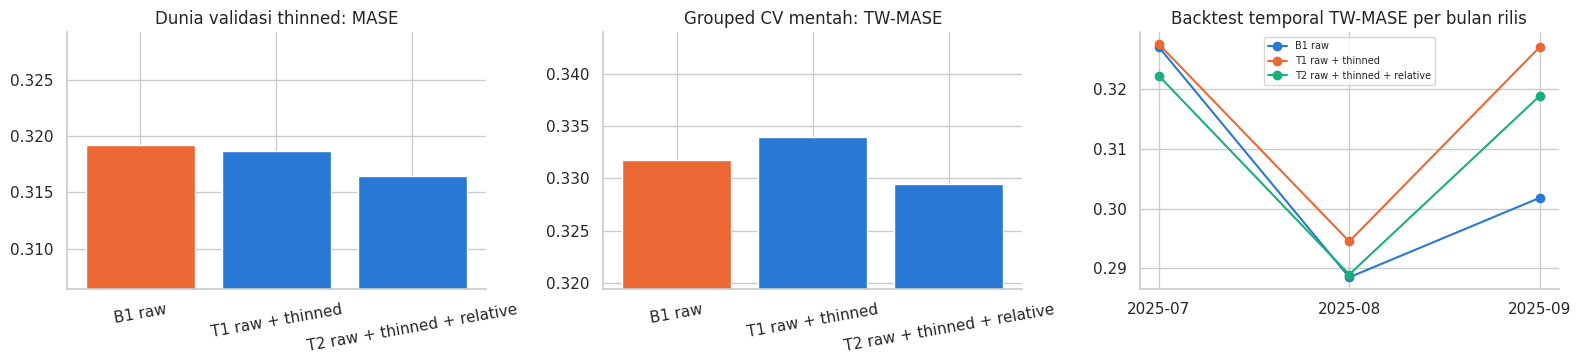

In [29]:
def film_delta_ci(p_new, p_ref, yy, ss, ww, gg):
    d = (np.abs(yy - p_new) - np.abs(yy - p_ref)) / ss * ww
    G = pd.DataFrame({'g': gg, 'd': d, 'w': ww}).groupby('g').sum()
    ix = np.random.default_rng(CFG.SEED).integers(0, len(G), (2000, len(G)))
    b = G.d.values[ix].sum(1) / G.w.values[ix].sum(1)
    return np.quantile(b, [0.025, 0.5, 0.975]), int((G.d < 0).sum()), len(G)


groups_q = base_title(XQ.movie_title).values
rows, PASS = [], {}
for cand in [n for n in RUNS if n != REF]:
    a_, b_ = L.loc[cand], L.loc[REF]
    lv = CONFIGS[cand]['level']
    checks = {'quiet_world_gain': b_.QW - a_.QW >= CFG.QW_MIN_GAIN,
              'proxy_test_period': PROXY.loc[('raw+thin', lv), 'test_period_mae'] < PROXY.loc[('raw', 'abs'), 'test_period_mae'],
              'guard_grouped_tw': a_.TW - b_.TW <= CFG.AUG_GUARD,
              'guard_temporal': a_.temporal_mean - b_.temporal_mean <= CFG.AUG_GUARD}
    PASS[cand] = all(checks.values())
    ciq, bq_, nq_ = film_delta_ci(RUNS[cand]['comp'][2], RUNS[REF]['comp'][2], yq, sq, np.ones(len(yq)), groups_q)
    ci, br_, nr_ = film_delta_ci(RUNS[cand]['comp'][0], RUNS[REF]['comp'][0], y, s, TW, groups)
    rows.append(dict(candidate=cand, adopted=PASS[cand], **checks, quiet_world_ci95=f'[{ciq[0]:+.4f}, {ciq[2]:+.4f}]',
                     quiet_films_better=f'{bq_}/{nq_}', grouped_ci95=f'[{ci[0]:+.4f}, {ci[2]:+.4f}]', grouped_films_better=f'{br_}/{nr_}'))
display(pd.DataFrame(rows).set_index('candidate'))
ok_ = [n for n, v in PASS.items() if v]
SELECTED = min(ok_, key=lambda n: L.loc[n, 'QW']) if ok_ else REF
SEL = RUNS[SELECTED]
SEL_A = SEL['a']
SEL_FEATS = SEL['frames'][0][2]
for n_, R_ in RUNS.items():
    if n_ != SELECTED:
        R_.pop('frames', None)
        for t_ in R_['temporal'].values():
            t_.pop('frames', None)
print(f'SELECTED configuration: {SELECTED} | features {len(SEL_FEATS)} | pull a {SEL_A:.3f} (training frames of other configurations freed)')

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
names_ = list(L.index)
for a_x, col, title in [(ax[0], 'QW', 'Dunia validasi thinned: MASE'), (ax[1], 'TW', 'Grouped CV mentah: TW-MASE')]:
    a_x.bar(range(len(names_)), L[col], color=[PAL[1] if n_ == SELECTED else PAL[0] for n_ in names_])
    a_x.set_xticks(range(len(names_)), names_, rotation=10); a_x.set(title=title, ylim=(L[col].min() - .01, L[col].max() + .01))
for n_ in names_:
    ax[2].plot(MONTHS, L.loc[n_, [f'temp_{m}' for m in MONTHS]].values, marker='o', label=n_)
ax[2].set(title='Backtest temporal TW-MASE per bulan rilis'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'augmentation_decision.png'); plt.show()

#### Insights

> Lookup lokal (`eda/88`) memberi ekspektasi: di dunia validasi thinned, model yang dilatih mentah kehilangan sekitar 0,03 MASE dibanding di dunia mentah, dan augmentasi mengembalikan sekitar 0,025 darinya, dengan biaya sekitar 0,003 di dunia mentah. Selisih antara MASE dunia validasi model B1 dan grouped CV mentahnya adalah perkiraan offset yang selama ini terlihat antara validasi dan leaderboard; bila thinning memang meniru periode uji, MASE dunia validasi B1 seharusnya dekat ke level public v13 setelah memperhitungkan baris Lebaran.

> Bila kandidat gagal, notebook kembali ke B1 secara otomatis. Interval bootstrap per film yang melewati nol berarti perbaikan belum kokoh dan harus dibaca bersama lensa lain.

## Sensitivitas $\lambda$

$\lambda$ LightGBM dibekukan 0,5 dengan $a$ dari proxy yang bersesuaian. Tabel berikut memperlihatkan arah sensitivitas pada konfigurasi terpilih.

In [30]:
lam_rows = []
for lam in (0.0, 0.25, 0.5, 0.75, 1.0):
    r = lens(*lgb_component(SEL, lam))
    lam_rows.append(dict(lam=lam, QW=r['QW'], TW=r['TW'], temporal_mean=r['temporal_mean']))
display(pd.DataFrame(lam_rows).set_index('lam').round(4))
oof_lgbmix = SEL['comp'][0]
for n_, R_ in RUNS.items():
    results.append(score(R_['comp'][0], f'LightGBM mix [{n_}]'))

,QW,TW,temporal_mean
lam,,,
0.00,0.3240,0.3283,0.3041
0.25,0.3209,0.3295,0.3041
0.50,0.3192,0.3318,0.3058
0.75,0.3186,0.3351,0.3077
1.00,0.3189,0.3398,0.3109


LightGBM mix [B1 raw]                    MASE 0.3132 | TW-MASE 0.3318 | s<=20 0.8207 | s>200 0.2633
LightGBM mix [T1 raw + thinned]          MASE 0.3136 | TW-MASE 0.3339 | s<=20 0.8482 | s>200 0.2604
LightGBM mix [T2 raw + thinned + relative] MASE 0.3099 | TW-MASE 0.3295 | s<=20 0.8357 | s>200 0.2579


## Kandidat Foundation Model: TabPFN-3.5 Fast FP16

TabPFN-3.5 Fast ([Prior-Labs/tabpfn_3_5](https://huggingface.co/Prior-Labs/tabpfn_3_5), `tabpfn-v3.5-fast-20260909.safetensors`, revisi `06bf2ba3`, SHA-256 `14e0b812...`) adalah model in-context dari Prior Labs, keluarga yang sama dengan TabPFN-3.5 di v8 (public terbaik, checkpoint 876 MB melanggar batas 200 MB), tetapi versi Fast dengan 8 layer, bukan 24. Berkas aslinya float32 334,2 MB. Notebook mengunduhnya pada revisi terkunci, memverifikasi SHA-256, lalu menyimpan setiap matriks (tensor float32 berdimensi 2 atau lebih) sebagai float16; vektor dan border regresi tetap float32 (167,2 MB, galat bobot relatif 0,00017). Berkas FP16 inilah yang dipakai dari validasi sampai inferensi final dan disimpan di berkas bobot. Di v13 Fast mengalahkan TabPFN-2.5 Quantiles di backtest temporal (0,3000 vs 0,3092) dan lensa pasar sepi (0,3054 vs 0,3081), dengan korelasi galat 0,989, sehingga v14 hanya memakai Fast (TabPFN-2.5 tetap bisa diaktifkan lewat `FM_LIST`).

Model dipakai per horizon (tanpa `h`). Konteksnya semua baris mentah dari bagian latih, ditambah sampel baris dunia thinned (seed tetap) sampai `FM_CTX` baris per horizon. Satu konteks dipakai untuk memprediksi baris mentah dan baris dunia validasi sekaligus. **Status kepatuhan tanggal:** checkpoint dirilis setelah 30 September 2025; batas tanggal dibaca berlaku untuk data eksternal, bukan pretrained model, sesuai keputusan tim (belum dikonfirmasi panitia). `FM_LIST = ('tabpfn_v2',)` (revisi 11 Juni 2025, 44,4 MB) atau `()` tersedia untuk tafsiran ketat.

In [31]:
TAB_QS = CFG.TAB_QS


def hf_token():
    if os.environ.get('HF_TOKEN'):
        return os.environ['HF_TOKEN']
    if UserSecretsClient is not None:
        try:
            return UserSecretsClient().get_secret('HF_TOKEN')
        except Exception:
            return None
    return None


def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()


def find_local(fname):
    roots = [Path('/kaggle/input')] if CFG._ON_KAGGLE else []
    for root in roots:
        hit = [p for p in root.rglob(Path(fname).name) if str(p).endswith(fname)]
        if hit:
            return str(hit[0])
        for pk in root.rglob('*.pkl'):
            try:
                with open(pk, 'rb') as f:
                    blob = pickle.load(f).get('fm_files', {})
            except Exception:
                continue
            if fname in blob:
                out = CFG.OUTPUT_DIR / 'fm' / fname
                out.parent.mkdir(parents=True, exist_ok=True)
                out.write_bytes(blob[fname])
                return str(out)
    return None


def checkpoint_path(repo, fname, rev, digest):
    # local_dir keeps the real file name: loaders pick the format from the suffix
    path = find_local(fname) or hf_hub_download(repo, fname, revision=rev, token=hf_token(), local_dir=str(CFG.OUTPUT_DIR / 'fm'))
    got = sha256(path)
    if got != digest:
        raise RuntimeError(f'{fname}: SHA-256 {got} does not match the pinned revision ({digest})')
    print(f'{fname}: SHA-256 verified ({path})')
    return path


def fast16_checkpoint():
    hit = find_local(CFG.FAST16_FILE)
    if hit:
        print(f'{CFG.FAST16_FILE}: found ({hit}), SHA-256 {sha256(hit)}')
        return hit
    src = checkpoint_path(CFG.FAST_REPO, CFG.FAST_FILE, CFG.FAST_REV, CFG.FAST_SHA256)
    out = CFG.OUTPUT_DIR / 'fm' / CFG.FAST16_FILE
    out.parent.mkdir(parents=True, exist_ok=True)
    arrays, err, ref = {}, 0.0, 0.0
    with safe_open(src, framework='np') as f:
        meta = f.metadata()
        for k_ in f.keys():
            a = f.get_tensor(k_)
            b = a.astype(np.float16) if (a.dtype == np.float32 and a.ndim >= 2) else a
            assert np.isfinite(b).all(), k_
            err += float(np.square(b.astype(np.float64) - a).sum())
            ref += float(np.square(a.astype(np.float64)).sum())
            arrays[k_] = b
    save_file(arrays, str(out), metadata=meta)
    Path(src).unlink()
    print(f'{CFG.FAST16_FILE}: {out.stat().st_size / 1e6:.1f} MB, relative weight L2 error {np.sqrt(err / ref):.6f}, SHA-256 {sha256(out)}')
    return str(out)


FM_SPEC = {'tabpfn25q': (ModelVersion.V2_5, CFG.TP25_REPO, CFG.TP25_FILE, CFG.TP25_REV, CFG.TP25_SHA256),
           'tabpfn_v2': (ModelVersion.V2, CFG.TABPFN_REPO, CFG.TABPFN_FILE, CFG.TABPFN_REV, CFG.TABPFN_SHA256),
           'fast35': (ModelVersion.V3_5, CFG.FAST_REPO, CFG.FAST16_FILE, CFG.FAST_REV, CFG.FAST_SHA256)}


def context_rows(Xa, ia):
    idx = np.where(ia)[0]
    raw_ = idx[(Xa.world.values[idx] == 'raw')]
    thin_ = idx[(Xa.world.values[idx] != 'raw')]
    room = max(CFG.FM_CTX - len(raw_), 0)
    if len(thin_) > room:
        thin_ = np.sort(np.random.default_rng(CFG.SEED).choice(thin_, room, replace=False))
    return np.concatenate([raw_, thin_])


def make_tabpfn(version, ckpt):
    def fn(Xa, Xbs, feats):
        tf = [c for c in feats if c != 'h']
        outs = [np.zeros((len(X_), len(TAB_QS))) for X_ in Xbs]
        ya = r_target(Xa)
        for hz in range(4, 11):
            ia = context_rows(Xa, (Xa.h == hz).values)
            m = TabPFNRegressor.create_default_for_version(version, model_path=ckpt, device=CFG.DEVICE,
                                                           n_estimators=CFG.FM_EST, random_state=CFG.SEED, ignore_pretraining_limits=True)
            m.fit(Xa.iloc[ia][tf].values.astype(np.float32), ya[ia])
            for X_, o_ in zip(Xbs, outs):
                ib = (X_.h == hz).values
                if ib.sum() == 0:
                    continue
                Qb = X_[ib][tf].values.astype(np.float32)
                o_[ib] = np.concatenate([np.asarray(m.predict(Qb[i:i + 3000], output_type='quantiles', quantiles=list(TAB_QS))).T
                                         for i in range(0, len(Qb), 3000)])
            del m
            torch.cuda.empty_cache()
        return [np.sort(o_, axis=1) for o_ in outs]
    return fn


def quant_median(Q, lam, a):
    p0 = np.array([np.interp(CFG.ZERO_EPS, q, TAB_QS, left=0.0, right=1.0) for q in Q])
    p = sigm(logit(np.clip(p0, 1e-4, 1 - 1e-4)) + lam * a)
    u = np.clip(p0 + (1 - p0) * (0.5 - p) / (1 - p), TAB_QS[0], TAB_QS[-1])
    val = np.array([np.interp(ui, TAB_QS, qi) for ui, qi in zip(u, Q)])
    return np.where(p >= 0.5, 0.0, np.clip(val, 0, None))


def run_quant(fn, R):
    oof, oofq = np.zeros((len(Xtr), len(TAB_QS))), np.zeros((len(XQ), len(TAB_QS)))
    for k in range(CFG.N_FOLDS):
        Xa_, Xbs_, f_ = R['frames'][k]
        oof[FOLD == k], oofq[FOLD_Q == k] = fn(Xa_, Xbs_, f_)
    return oof, {m: fn(t['frames'][0], t['frames'][1], t['frames'][2])[0] for m, t in R['temporal'].items()}, oofq


QUANT, QFN, FM_CKPT, SIZE_MB, FM_TIME = {}, {}, {}, {'lgb': SEL['lgb_mb']}, {}
for n in CFG.FM_LIST:
    t0 = time.time()
    try:
        FM_CKPT[n] = fast16_checkpoint() if n == 'fast35' else checkpoint_path(*FM_SPEC[n][1:])
        QFN[n] = make_tabpfn(FM_SPEC[n][0], FM_CKPT[n])
        QUANT[n] = run_quant(QFN[n], SEL)
        SIZE_MB[n] = Path(FM_CKPT[n]).stat().st_size / 1e6
        FM_TIME[n] = time.time() - t0
        print(f'{n}: CV + temporal (raw and validation-world predictions) {FM_TIME[n]:.0f}s | checkpoint {SIZE_MB[n]:.1f} MB')
    except Exception as e:
        if CFG.STRICT:
            raise
        print(f'{n} skipped:', type(e).__name__, str(e)[:300])

tabpfn-v3.5-fast-20260909.safetensors:   0%|          | 0.00/334M [00:00<?, ?B/s]

tabpfn-v3.5-fast-20260909.safetensors: SHA-256 verified (/kaggle/working/fm/tabpfn-v3.5-fast-20260909.safetensors)
tabpfn-v3.5-fast-matrix-fp16.safetensors: 167.2 MB, relative weight L2 error 0.000172, SHA-256 8c4074bf0a0de932049dd2d1db4308bc029d7940fcef873f98f9e81b71b938ce
fast35: CV + temporal (raw and validation-world predictions) 755s | checkpoint 167.2 MB


## Kandidat: TabM

TabM ([yandex-research/tabm](https://github.com/yandex-research/tabm), paket `tabm==0.0.3`, lisensi Apache-2.0) bukan foundation model pretrained: satu MLP yang secara efisien mewakili ensemble $k = 32$ submodel (BatchEnsemble), dilatih dari nol pada bagian latih yang sama dengan LightGBM, termasuk dunia thinned bila konfigurasi terpilih memakainya. Penerapannya sama dengan v12 dan v13: satu model untuk semua horizon, 10% film bagian latih untuk early stopping ditentukan lebih dulu (semua dunia film itu ikut ke sisi early stopping), fitur konstan dibuang, median imputasi, `QuantileTransformer`, dan 48 bin *piecewise-linear embeddings* di-fit hanya pada inner-training, 49 kuantil $r$ dengan pinball loss berbobot $c_{mult}$. Satu model dipakai untuk memprediksi baris mentah dan dunia validasi sekaligus.

In [32]:
TABM_LAST = {}


def pinball(pred, target, w, taus):
    d = target[:, None, None] - pred
    loss = torch.maximum(taus * d, (taus - 1) * d).mean(dim=(1, 2))
    return (loss * w).sum() / w.sum()


def tabm_quantiles(Xa, Xbs, feats):
    torch.manual_seed(CFG.SEED)
    np.random.seed(CFG.SEED)
    gA = base_title(Xa.movie_title).values
    ugA = np.array(sorted(set(gA)))
    iv = np.isin(gA, np.random.RandomState(CFG.SEED).permutation(ugA)[: max(1, len(ugA) // 10)])
    # every input statistic is fitted on the inner-training films only (early-stopping films stay unseen)
    fit_part = Xa[~iv]
    use = [f for f in feats if fit_part[f].nunique(dropna=True) > 1]
    med = fit_part[use].median()
    qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, subsample=10 ** 9, random_state=CFG.SEED)
    qt.fit(fit_part[use].fillna(med).values)
    prep = lambda X: qt.transform(X[use].fillna(med).values).astype(np.float32)
    A = prep(Xa)
    yA, wA = r_target(Xa).astype(np.float32), Xa.cal_mult.values.astype(np.float32)
    dev = torch.device(CFG.DEVICE)
    T = lambda a: torch.as_tensor(a, device=dev)
    Xt, yt, wt, Xv, yv, wv = T(A[~iv]), T(yA[~iv]), T(wA[~iv]), T(A[iv]), T(yA[iv]), T(wA[iv])
    bins = compute_bins(torch.as_tensor(A[~iv]), n_bins=CFG.TABM_BINS)
    model = TabM.make(n_num_features=A.shape[1], d_out=len(TAB_QS), k=CFG.TABM_K,
                      num_embeddings=PiecewiseLinearEmbeddings(bins, CFG.TABM_DEMB, activation=False, version='B')).to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.TABM_LR, weight_decay=CFG.TABM_WD)
    taus = T(np.asarray(TAB_QS, dtype=np.float32))
    gen = torch.Generator().manual_seed(CFG.SEED)
    best, best_state, bad = np.inf, None, 0
    for epoch in range(CFG.TABM_EPOCHS):
        model.train()
        perm = torch.randperm(len(Xt), generator=gen).to(dev)
        for i in range(0, len(Xt), CFG.TABM_BATCH):
            b = perm[i:i + CFG.TABM_BATCH]
            loss = pinball(model(Xt[b]), yt[b], wt[b], taus)
            opt.zero_grad()
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = pinball(torch.cat([model(Xv[i:i + 4096]) for i in range(0, len(Xv), 4096)]), yv, wv, taus).item()
        if vl < best - 1e-6:
            best, bad = vl, 0
            best_state = {k_: v_.detach().clone() for k_, v_ in model.state_dict().items()}
        else:
            bad += 1
            if bad >= CFG.TABM_PATIENCE:
                break
    model.load_state_dict(best_state)
    model.eval()
    outs = []
    with torch.no_grad():
        for X_ in Xbs:
            B = prep(X_)
            outs.append(np.sort(torch.cat([model(T(B[i:i + 4096])).mean(dim=1) for i in range(0, len(B), 4096)]).cpu().numpy(), axis=1))
    TABM_LAST.update(state=best_state, qt=qt, median=med, feats=use, dropped_constant=[f for f in feats if f not in use],
                     bins=bins, epochs=epoch + 1, val_pinball=best)
    return outs


def tabm_blob():
    buf = io.BytesIO()
    torch.save({k_: v_.cpu() for k_, v_ in TABM_LAST['state'].items()}, buf)
    return {'state': zlib.compress(buf.getvalue(), 9), 'quantile_transformer': pickle.dumps(TABM_LAST['qt']),
            'fill_median': TABM_LAST['median'].to_dict(), 'features': TABM_LAST['feats'],
            'bins': [b_.cpu().numpy() for b_ in TABM_LAST['bins']], 'k': CFG.TABM_K, 'd_embedding': CFG.TABM_DEMB}


if CFG.USE_TABM:
    t0 = time.time()
    QUANT['tabm'], QFN['tabm'] = run_quant(tabm_quantiles, SEL), tabm_quantiles
    SIZE_MB['tabm'] = len(pickle.dumps(tabm_blob())) / 1e6
    print(f'TabM: CV + temporal {time.time() - t0:.0f}s | last fit stopped after {TABM_LAST["epochs"]} epochs | '
          f'size {SIZE_MB["tabm"]:.1f} MB | constant features dropped in the last fit: {TABM_LAST["dropped_constant"]}')
print('component sizes (MB):', {k: round(v, 1) for k, v in SIZE_MB.items()})

TabM: CV + temporal 221s | last fit stopped after 9 epochs | size 6.2 MB | constant features dropped in the last fit: ['t_ramadan', 'cin_new']
component sizes (MB): {'lgb': 20.1, 'fast35': 167.2, 'tabm': 6.2}


## Koreksi Pencopotan per Model

Setiap model kuantil dinilai dengan **median langsung** ($\lambda = 0$) dan **dengan koreksi** ($\lambda = 0{,}5$, $a$ dari proxy konfigurasi terpilih) pada tiga lensa: MASE dunia validasi, TW-MASE grouped CV mentah, dan rata-rata backtest temporal. Varian dengan regret maksimum terkecil dipakai.

In [33]:
lenses_ = ['QW', 'TW', 'temporal_mean']
LAM_CHOICE = {}
COMP = {'lgb': SEL['comp']}


def quant_component(oq, tq, qq, lam, R):
    a = R['a']
    return (quant_median(oq, lam, a) * cm * s,
            {m: (t['idx'], quant_median(tq[m], lam, a) * cm[t['idx']] * s[t['idx']]) for m, t in R['temporal'].items()},
            quant_median(qq, lam, a) * cmq * sq)


rows = []
for n, (oq, tq, qq) in QUANT.items():
    for lam in (0.0, CFG.LAMBDA):
        rows.append(dict(model=n, lam=lam, **lens(*quant_component(oq, tq, qq, lam, SEL))))
VAR = pd.DataFrame(rows)
if len(VAR):
    display(VAR[['model', 'lam'] + lenses_ + [f'temp_{m}' for m in MONTHS]].round(4))
    for n, g in VAR.groupby('model'):
        reg = (g[lenses_] - g[lenses_].min()).max(axis=1)
        LAM_CHOICE[n] = float(g.loc[reg.idxmin(), 'lam'])
        COMP[n] = quant_component(*QUANT[n], LAM_CHOICE[n], SEL)
        results.append(score(COMP[n][0], f'{n} median (lambda {LAM_CHOICE[n]})'))
print('pull-shift choice per model:', LAM_CHOICE)
display(pd.DataFrame({n: lens(*COMP[n]) for n in COMP}).T[lenses_ + ['QW_TW', 'MASE']].round(4))

,model,lam,QW,TW,temporal_mean,temp_2025-07,temp_2025-08,temp_2025-09
0,fast35,0.0,0.3361,0.3252,0.3047,0.3160,0.3029,0.2951
1,fast35,0.5,0.3252,0.3292,0.3000,0.3134,0.3005,0.2861
2,tabm,0.0,0.3369,0.3354,0.3129,0.3208,0.3145,0.3033
3,tabm,0.5,0.3365,0.3398,0.3157,0.3238,0.3165,0.3067


fast35 median (lambda 0.5)               MASE 0.3147 | TW-MASE 0.3292 | s<=20 0.8117 | s>200 0.2673
tabm median (lambda 0.0)                 MASE 0.3202 | TW-MASE 0.3354 | s<=20 0.8318 | s>200 0.2748
pull-shift choice per model: {'fast35': 0.5, 'tabm': 0.0}


,QW,TW,temporal_mean,QW_TW,MASE
lgb,0.3192,0.3318,0.3058,0.3413,0.3132
fast35,0.3252,0.3292,0.3000,0.3457,0.3147
tabm,0.3369,0.3354,0.3129,0.3569,0.3202


## Blending dengan Batas Bobot 200 MB

Bobot komponen dicari pada grid simpleks berjarak 0,1. Batas keras: paling banyak satu TabPFN dan total ukuran komponen berbobot positif ditambah `SIZE_MARGIN_MB` tidak melewati 200 MB. Kombinasi hanya boleh dipakai bila, terhadap LightGBM saja: (1) MASE dunia validasi membaik minimal `BLEND_MIN_GAIN` (0,001), (2) TW grouped CV mentah tidak memburuk lebih dari 0,002, dan (3) backtest temporal tidak memburuk lebih dari 0,002. Di antara yang lolos dipilih kombinasi dengan **regret maksimum terkecil** atas tiga lensa.

In [34]:
names = list(COMP)
base_l = lens(*COMP['lgb'])
grid = np.round(np.arange(0, 1.01, 0.1), 1)
FM_NAMES = [n for n in names if n in FM_SPEC]
rows = []
for w in itertools.product(grid, repeat=len(names)):
    if abs(sum(w) - 1) > 1e-9:
        continue
    ws = {n: wi for n, wi in zip(names, w) if wi > 0}
    if sum(n in FM_NAMES for n in ws) > 1:
        continue
    mb = sum(SIZE_MB.get(n, 0.0) for n in ws)
    rows.append(dict(zip([f'w_{n}' for n in names], w), size_mb=mb, **lens(*blend(ws, COMP))))
BW = pd.DataFrame(rows)
BW['max_regret'] = (BW[lenses_] - BW[lenses_].min()).max(axis=1)
BW['fits'] = BW.size_mb + CFG.SIZE_MARGIN_MB <= CFG.MAX_WEIGHTS_MB
BW['pass'] = (BW.fits & (BW['w_lgb'] < 1) & (base_l['QW'] - BW.QW >= CFG.BLEND_MIN_GAIN)
              & (BW.TW <= base_l['TW'] + 0.002) & (BW.temporal_mean <= base_l['temporal_mean'] + 0.002))
wcols = [f'w_{n}' for n in names]
print(f'{len(BW)} weight combinations, {int(BW.fits.sum())} fit 200 MB, {int(BW["pass"].sum())} pass every condition')
display(BW.sort_values('max_regret').head(10)[wcols + ['size_mb'] + lenses_ + ['max_regret', 'pass']].round(4))
WEIGHTS = {'lgb': 1.0}
if BW['pass'].any():
    ok_ = BW[BW['pass']]
    pick = ok_.loc[ok_.max_regret.idxmin()]
    WEIGHTS = {n: float(pick[f'w_{n}']) for n in names if pick[f'w_{n}'] > 0}
    print('best by the validation world only:', {k[2:]: v for k, v in ok_.loc[ok_.QW.idxmin(), wcols].to_dict().items() if v > 0})
print('signed-error correlation (validation world):')
display(pd.DataFrame({n: (yq - COMP[n][2]) / sq for n in names}).corr().round(3))
oof_final, tp_final, qp_final = blend(WEIGHTS, COMP)
FEATURE_CFG = SELECTED
print('chosen weights:', WEIGHTS, '| estimated weights size', round(sum(SIZE_MB.get(n, 0) for n in WEIGHTS), 1), 'MB')
results.append(score(oof_final, 'final blend'))
display(pd.DataFrame(results).set_index('model').round(4))
FINAL_L = pd.DataFrame({'final': lens(oof_final, tp_final, qp_final), 'LightGBM only': base_l, 'B1 LightGBM (v13 recipe)': lens(*RUNS[REF]['comp'])}).T
display(FINAL_L[lenses_ + ['QW_TW', 'MASE']].round(4))

66 weight combinations, 66 fit 200 MB, 0 pass every condition


,w_lgb,w_fast35,w_tabm,size_mb,QW,TW,temporal_mean,max_regret,pass
49,0.5,0.4,0.1,193.5071,0.3190,0.3274,0.2999,0.0009,False
48,0.5,0.3,0.2,193.5071,0.3192,0.3272,0.3001,0.0011,False
50,0.5,0.5,0.0,187.3447,0.3193,0.3280,0.3001,0.0013,False
43,0.4,0.5,0.1,193.5071,0.3197,0.3272,0.2994,0.0014,False
42,0.4,0.4,0.2,193.5071,0.3198,0.3269,0.2995,0.0014,False
54,0.6,0.3,0.1,193.5071,0.3186,0.3279,0.3007,0.0017,False
44,0.4,0.6,0.0,187.3447,0.3201,0.3278,0.2997,0.0017,False
47,0.5,0.2,0.3,193.5071,0.3197,0.3274,0.3007,0.0017,False
55,0.6,0.4,0.0,187.3447,0.3188,0.3284,0.3008,0.0018,False
41,0.4,0.3,0.3,193.5071,0.3203,0.3270,0.3000,0.0019,False


signed-error correlation (validation world):


,lgb,fast35,tabm
lgb,1.000,0.990,0.986
fast35,0.990,1.000,0.986
tabm,0.986,0.986,1.000


chosen weights: {'lgb': 1.0} | estimated weights size 20.1 MB
final blend                              MASE 0.3132 | TW-MASE 0.3318 | s<=20 0.8207 | s>200 0.2633


,MASE,TW_MASE,small,big
model,,,,
"median r/c by (h, D1 dow)",0.4002,0.4330,0.9822,0.3279
LightGBM mix [B1 raw],0.3132,0.3318,0.8207,0.2633
LightGBM mix [T1 raw + thinned],0.3136,0.3339,0.8482,0.2604
LightGBM mix [T2 raw + thinned + relative],0.3099,0.3295,0.8357,0.2579
fast35 median (lambda 0.5),0.3147,0.3292,0.8117,0.2673
tabm median (lambda 0.0),0.3202,0.3354,0.8318,0.2748
final blend,0.3132,0.3318,0.8207,0.2633


,QW,TW,temporal_mean,QW_TW,MASE
final,0.3192,0.3318,0.3058,0.3413,0.3132
LightGBM only,0.3192,0.3318,0.3058,0.3413,0.3132
B1 LightGBM (v13 recipe),0.3192,0.3318,0.3058,0.3413,0.3132


#### Insights

> Model dibandingkan pada bagian latih yang sama, sehingga perbedaan antar baris tabel adalah perbedaan model. Baris `B1 LightGBM (v13 recipe)` memperlihatkan seberapa jauh resep v14 bergerak dari resep v13 pada setiap lensa. Selisih di bawah sekitar 0,002 berada di dalam noise bootstrap per film, jadi bobot yang berdekatan tidak boleh dibaca sebagai jaminan public atau private.

---

# Evaluation <a name="9"></a>

---

Galat out-of-fold model final dibedah per bucket skala, per horizon, per bulan rilis, dan per film. Kontribusi per bucket dihitung dengan porsi uji, dan sensitivitas skor terhadap komposisi film diukur dengan bootstrap per film.

,test_share,train_share,mase,zero_rate,contribution_to_test
scale,,,,,
"(0.0, 5.0]",0.015,0.003,2.593,0.758,0.040
"(5.0, 20.0]",0.114,0.029,0.647,0.761,0.074
"(20.0, 50.0]",0.198,0.101,0.412,0.622,0.082
"(50.0, 100.0]",0.200,0.169,0.321,0.520,0.064
"(100.0, 200.0]",0.195,0.235,0.295,0.333,0.057
"(200.0, 500.0]",0.178,0.276,0.279,0.151,0.050
"(500.0, 1000000000.0]",0.100,0.188,0.240,0.026,0.024


TW-MASE by horizon: {4: 0.426, 5: 0.454, 6: 0.326, 7: 0.32, 8: 0.267, 9: 0.262, 10: 0.267}
TW-MASE by release month: {'2025-04': 0.374, '2025-05': 0.475, '2025-06': 0.282, '2025-07': 0.308, '2025-08': 0.277, '2025-09': 0.284}
top-5 films carry 28.1% of the weighted error: ['LILO & STITCH', 'SAYAP SAYAP PATAH 2: OLIVIA', 'SORE ISTRI DARI MASA DEPAN', 'UNTIL DAWN', 'WEAPONS']
final vs B1 LightGBM film bootstrap 95% CI of TW change: [+0.0000, +0.0000] | films better 0/126
final vs B1 LightGBM on the validation world: 95% CI [+0.0000, +0.0000] | films better 0/126


raw (TW)                      validation world          \
                          B1   final weight share               B1   final   
target zero           0.1294  0.1294       0.4277           0.0928  0.0928   
target positive       0.4830  0.4830       0.5723           0.4163  0.4163   
growth (y > D3)       1.0487  1.0487       0.1693           0.8864  0.8864   
positive, no growth   0.2452  0.2452       0.4029           0.2445  0.2445   
D4-D5                 0.4397  0.4397       0.2861           0.3749  0.3749   
scale <= 20           0.5444  0.5444       0.1296           0.5501  0.5501   

                                  
                    weight share  
target zero               0.3001  
target positive           0.6999  
growth (y > D3)           0.1873  
positive, no growth       0.5127  
D4-D5                     0.2861  
scale <= 20               0.1165

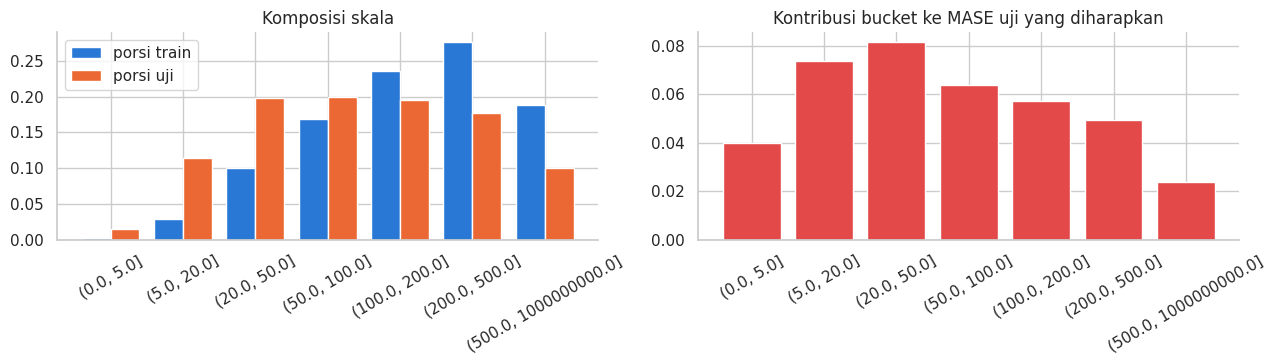

In [35]:
E = Xtr[['movie_title', 'h', 'scale', 'total_ticket', 'd1']].assign(pred=oof_final, w=TW)
E['ae'] = np.abs(E.total_ticket - E.pred) / E.scale
cut = pd.cut(E.scale, CFG.TW_BINS)
bk = pd.DataFrame({'test_share': pd.cut(Xte.scale, CFG.TW_BINS).value_counts(normalize=True), 'train_share': cut.value_counts(normalize=True),
                   'mase': E.groupby(cut, observed=False).ae.mean(), 'zero_rate': (E.total_ticket == 0).groupby(cut, observed=False).mean()}).sort_index()
bk['contribution_to_test'] = bk.test_share * bk.mase
display(bk.round(3))
wm = lambda g: np.average(g.ae, weights=g.w)
print('TW-MASE by horizon:', E.groupby('h').apply(wm, include_groups=False).round(3).to_dict())
print('TW-MASE by release month:', E.groupby(E.d1.dt.strftime('%Y-%m')).apply(wm, include_groups=False).round(3).to_dict())
fe = E.assign(c=E.ae * E.w / E.w.sum()).groupby(base_title(E.movie_title)).c.sum()
print(f'top-5 films carry {fe.nlargest(5).sum() / fe.sum():.1%} of the weighted error:', fe.nlargest(5).index.tolist())
ci, better, nf = film_delta_ci(oof_final, RUNS[REF]['comp'][0], y, s, TW, groups)
print(f'final vs B1 LightGBM film bootstrap 95% CI of TW change: [{ci[0]:+.4f}, {ci[2]:+.4f}] | films better {better}/{nf}')
ciq, betterq, nfq = film_delta_ci(qp_final, RUNS[REF]['comp'][2], yq, sq, np.ones(len(yq)), groups_q)
print(f'final vs B1 LightGBM on the validation world: 95% CI [{ciq[0]:+.4f}, {ciq[2]:+.4f}] | films better {betterq}/{nfq}')

seg_rows = {}
for wname, yy, ss, X_, ww, preds in [('raw (TW)', y, s, Xtr, TW, {'B1': RUNS[REF]['comp'][0], 'final': oof_final}),
                                     ('validation world', yq, sq, XQ, np.ones(len(yq)), {'B1': RUNS[REF]['comp'][2], 'final': qp_final})]:
    SEGS = {'target zero': yy == 0, 'target positive': yy > 0, 'growth (y > D3)': yy > X_.y3.values,
            'positive, no growth': (yy > 0) & (yy <= X_.y3.values), 'D4-D5': X_.h.values <= 5, 'scale <= 20': ss <= 20}
    for k, p in preds.items():
        seg_rows[(wname, k)] = {sg: np.average(np.abs(yy[m] - p[m]) / ss[m], weights=ww[m]) for sg, m in SEGS.items()}
    seg_rows[(wname, 'weight share')] = {sg: ww[m].sum() / ww.sum() for sg, m in SEGS.items()}
display(pd.DataFrame(seg_rows).round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
xx = np.arange(len(bk))
ax[0].bar(xx - .2, bk.train_share, .4, label='porsi train'); ax[0].bar(xx + .2, bk.test_share, .4, label='porsi uji')
ax[0].set_xticks(xx, [str(i) for i in bk.index], rotation=30); ax[0].legend(); ax[0].set_title('Komposisi skala')
ax[1].bar(xx, bk.contribution_to_test, color=PAL[7]); ax[1].set_xticks(xx, [str(i) for i in bk.index], rotation=30)
ax[1].set_title('Kontribusi bucket ke MASE uji yang diharapkan')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'evaluation.png'); plt.show()

#### Insights

> Pasangan dengan skala di bawah 50 hanya sekitar 13% baris train tetapi 33% baris uji dan menyumbang porsi terbesar MASE uji yang diharapkan. Lima film menyumbang kira-kira seperempat sampai sepertiga galat berbobot (`eda/51`), sehingga perbedaan versi di bawah lebar interval bootstrap per film tidak boleh dibaca sebagai perbaikan pasti.

> Tabel segmen memisahkan galat pada target nol, target positif, dan pertumbuhan setelah D3 (audit v12: v12 membaik pada nol tetapi memburuk pada film yang masih tumbuh). Segmen tumbuh adalah bagian dari segmen positif, bukan kelompok tambahan. Perbaikan yang hanya memindahkan galat dari satu segmen ke segmen lain harus terlihat di sini sebelum dipercaya.

---

# Inference & Submission <a name="10"></a>

---

Model final dilatih pada seluruh sampel (rilis luas dan rilis terbatas) dengan konfigurasi terpilih. Statistik klaster untuk data uji memakai seluruh train (masa lalu film uji). Tidak ada parameter yang disetel pada leaderboard.

## Minggu Lebaran: Analog Top-Down dari Lebaran 2025

Tujuh judul slate Lebaran 2026 dirilis 18 Maret, sehingga D4 sampai D10 mereka adalah Lebaran hari 1 sampai 7 (6,1% baris uji), periode yang tidak memiliki padanan di sampel latih. Namun `train.csv` dimulai 1 April 2025, yaitu Lebaran 2025 hari ke-2, sehingga total tiket per klaster selama minggu Lebaran 2025 teramati. Prediksi top-down: total slate per klaster pada Lebaran hari ke-$k$ = $\rho$ x total klaster pada Lebaran 2025 hari ke-$k$, dibagi ke pasangan menurut pangsa skala D1 sampai D3. Rasio klaster dirata-rata geometrik dengan rasio nasional agar tidak liar pada klaster kecil.

slate: ['DANUR: THE LAST CHAPTER', 'DANUR: THE LAST CHAPTER (IMAX 2D)', 'NA WILLA', 'PELANGI DI MARS', 'SENIN HARGA NAIK', 'SUZZANNA: SANTET DOSA DI ATAS DOSA', 'TUNGGU AKU SUKSES NANTI']
normal 2025 day 217072 | 2025 Lebaran week mean 593714 | 2026 slate mean D1-D3 167461
2026 slate: 1003361 seats/day at occupancy 17% | 2025 slate occupancy median 73%


,rho=0.4,rho=0.5,rho=0.7,rho=1.0,occupancy_needed_rho=0.5
D4 (Lebaran day 1),0.83,1.03,1.45,2.07,17.0
D5 (Lebaran day 2),1.10,1.38,1.93,2.76,23.0
D6 (Lebaran day 3),1.34,1.68,2.35,3.35,28.0
D7 (Lebaran day 4),1.51,1.89,2.64,3.77,31.0
D8 (Lebaran day 5),1.49,1.86,2.61,3.72,31.0
D9 (Lebaran day 6),1.58,1.98,2.77,3.96,33.0
D10 (Lebaran day 7),1.48,1.85,2.59,3.71,31.0


analog mean r by Lebaran day: {1: 1.09, 2: 1.45, 3: 1.78, 4: 2.01, 5: 1.98, 6: 2.1, 7: 1.98}


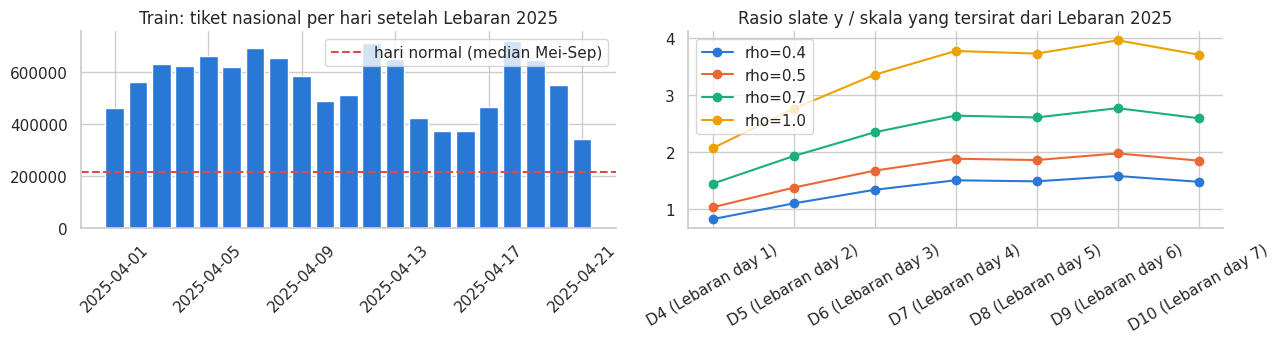

In [36]:
LEB25, LEB26 = pd.Timestamp('2025-03-31'), pd.Timestamp('2026-03-21')
leb_mask = Xte.date_show.between(LEB26, LEB26 + pd.Timedelta(days=6)).values
slate = sorted(Xte.movie_title[leb_mask].unique())
hsl = hist[hist.movie_title.isin(slate)]
day25 = train.groupby('date_show').total_ticket.sum()
normal_day = day25.loc['2025-05-01':].median()
m25 = pd.Series({k: day25[LEB25 + pd.Timedelta(days=k - 1)] for k in range(2, 8)})
m25.loc[1] = CFG.LEB_DAY1 * m25.loc[2]
m25 = m25.sort_index()
S26 = hsl.groupby('date_show').total_ticket.sum().mean()
seats26 = (hsl.total_ticket / (hsl.occupation_rate / 100).clip(lower=.005)).groupby(hsl.date_show).sum().mean()
top25 = train[train.date_show.between('2025-04-01', '2025-04-07')].groupby('movie_title').total_ticket.sum().nlargest(5).index
a25 = train[train.movie_title.isin(top25) & train.date_show.between('2025-04-01', '2025-04-07')]
print('slate:', slate)
print(f'normal 2025 day {normal_day:.0f} | 2025 Lebaran week mean {m25.loc[2:7].mean():.0f} | 2026 slate mean D1-D3 {S26:.0f}')
print(f'2026 slate: {seats26:.0f} seats/day at occupancy {100 * S26 / seats26:.0f}% | 2025 slate occupancy median {a25.occupation_rate.median():.0f}%')
imp_r = pd.DataFrame({f'rho={r_}': r_ * m25 / S26 for r_ in (0.4, 0.5, 0.7, 1.0)})
imp_r.index = [f'D{k + 3} (Lebaran day {k})' for k in imp_r.index]
imp_r['occupancy_needed_rho=0.5'] = (0.5 * m25.values / seats26 * 100).round(0)
display(imp_r.round(2))

c25 = {k: train[train.date_show == LEB25 + pd.Timedelta(days=k - 1)].groupby('cinema_ids').total_ticket.sum() for k in range(2, 8)}
c25[1] = CFG.LEB_DAY1 * c25[2]
c26 = hsl.groupby('cinema_ids').total_ticket.sum() / 3
kday = (Xte.date_show - LEB26).dt.days.values + 1
leb_pred = np.zeros(len(Xte))
for k in range(1, 8):
    m = leb_mask & (kday == k)
    r_nat = m25.loc[k] / S26
    r_cl = (Xte.cinema_ids[m].map(c25[k]) / Xte.cinema_ids[m].map(c26)).values
    r_cl = np.where(np.isfinite(r_cl) & (r_cl > 0), r_cl, r_nat)
    # geometric mean of cluster and national ratio
    leb_pred[m] = Xte.scale.values[m] * CFG.LEB_RHO * np.sqrt(r_cl * r_nat)
print('analog mean r by Lebaran day:', {int(k): round(float((leb_pred / Xte.scale.values)[leb_mask & (kday == k)].mean()), 2) for k in range(1, 8)})

dd = day25.loc['2025-04-01':'2025-04-21']
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(dd.index, dd.values, color=PAL[0]); ax[0].axhline(normal_day, color=PAL[7], ls='--', label='hari normal (median Mei-Sep)')
ax[0].set(title='Train: tiket nasional per hari setelah Lebaran 2025'); ax[0].legend(); ax[0].tick_params(axis='x', rotation=45)
imp_r[['rho=0.4', 'rho=0.5', 'rho=0.7', 'rho=1.0']].plot(ax=ax[1], marker='o'); ax[1].tick_params(axis='x', rotation=30)
ax[1].set(title='Rasio slate y / skala yang tersirat dari Lebaran 2025')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'lebaran.png'); plt.show()

#### Insights

> Minggu Lebaran 2025 berjalan di sekitar 608 ribu tiket per hari pada klaster yang sama (2,8 kali hari normal) dan tetap 2,3 sampai 3 kali normal pada hari kerja setelah cuti bersama. Slate 2026 sudah menawarkan sekitar satu juta kursi per hari pada D1 sampai D3 dengan okupansi hanya 15 sampai 23%, sedangkan slate Lebaran 2025 mencapai okupansi median 73%. Model statistik memprediksi slate turun ke sekitar 129 ribu tiket per hari (rasio 0,79, anjlok ke 0,25 pada 25 sampai 27 Maret), setara okupansi 13% pada minggu puncak tahunan, yang tidak masuk akal secara fisik.

> Analog memakai $\rho = 0{,}5$: slate diasumsikan hanya mencapai separuh total pasar Lebaran 2025 (rasio rata-rata sekitar 1,7, okupansi tersirat di bawah 35%). Bahkan skenario pesimis (pasar 60% dari 2025 dan pangsa slate 70%) memberi rasio 1,4. Nilai ini ditetapkan dari data 2025 dan kapasitas kursi, bukan dari leaderboard. Sumber eksternal pendukung yang terbit sebelum batas: pemberitaan April 2025 tentang 2 juta penonton dalam 3 hari libur Lebaran dan 5 juta penonton selama libur Lebaran.

In [37]:
t0 = time.time()
cfg_sel = RUNS[FEATURE_CFG]['cfg']
Xall = training_set(cfg_sel, lambda X_: np.ones(len(X_), dtype=bool))
XA, (XT,), feats_f, zfeats_f = make_parts(Xall, [Xte], cfg_sel, STATS_ALL)
print(f'final training rows {len(XA)} (worlds: {XA.world.value_counts().to_dict()})')
cm_te, s_te_ = Xte.cal_mult.values, Xte.scale.values
te_comp, final_lgb, lgb_mb = {}, None, 0.0
if WEIGHTS.get('lgb', 0) > 0:
    final_lgb = fit_lgb_all(XA, feats_f, zfeats_f)
    te_comp['lgb'] = lgb_mix(*predict_lgb_all(final_lgb, XT, feats_f, zfeats_f), CFG.LAMBDA, SEL_A) * cm_te * s_te_
    lgb_mb = lgb_size_mb(final_lgb)
est_mb = lgb_mb + sum(SIZE_MB[n] for n in WEIGHTS if n != 'lgb')
print(f'weights estimate: LightGBM {lgb_mb:.1f} MB + others {est_mb - lgb_mb:.1f} MB = {est_mb:.1f} MB')
assert est_mb + CFG.SIZE_MARGIN_MB <= CFG.MAX_WEIGHTS_MB, 'weights would exceed the 200 MB rule'
for n in WEIGHTS:
    if n != 'lgb':
        te_comp[n] = quant_median(QFN[n](XA, [XT], feats_f)[0], LAM_CHOICE[n], SEL_A) * cm_te * s_te_
assert set(te_comp) == set(WEIGHTS), f'component mismatch {set(te_comp)} vs {set(WEIGHTS)}'
pred = np.clip(sum(WEIGHTS[n] * te_comp[n] for n in te_comp), 0, None)
print('model mean r on Lebaran rows:', round(float((pred / s_te_)[leb_mask].mean()), 3), '-> analog', round(float((leb_pred / s_te_)[leb_mask].mean()), 3))
pred = np.where(leb_mask, leb_pred, pred)
print(f'final fit + inference: {time.time() - t0:.0f}s')

seg = pd.Series('normal', index=Xte.index)
for n, (a, b) in SEGMENTS.items():
    seg[Xte.date_show.between(a, b)] = n
rr = pred / s_te_
display(pd.DataFrame({'rows': seg.value_counts(), 'mean_r_hat': pd.Series(rr).groupby(seg.values).mean(),
                      'pred_zero_share': pd.Series(rr < .05).groupby(seg.values).mean()}).round(3))
bk_te = pd.cut(Xte.scale, CFG.TW_BINS).astype(str).values
bk_tr = pd.cut(Xtr.scale, CFG.TW_BINS).astype(str).values
display(pd.DataFrame({'test rows': pd.Series(bk_te).value_counts(), 'test mean r_hat / c_mult': pd.Series(rr / cm_te).groupby(bk_te).mean(),
                      'OOF mean r_hat / c_mult': pd.Series(oof_final / s / cm).groupby(bk_tr).mean(),
                      'OOF mean r / c_mult': pd.Series(y / s / cm).groupby(bk_tr).mean()}).round(3))

final training rows 57807 (worlds: {'raw': 57807})
weights estimate: LightGBM 20.1 MB + others 0.0 MB = 20.1 MB
model mean r on Lebaran rows: 0.867 -> analog 1.769
final fit + inference: 97s


,rows,mean_r_hat,pred_zero_share
lebaran,4417,1.769,0.000
normal,50551,0.505,0.280
ramadan,12408,0.416,0.404
xmas,5235,0.645,0.056


,test rows,test mean r_hat / c_mult,OOF mean r_hat / c_mult,OOF mean r / c_mult
"(0.0, 5.0]",1120,0.402,0.507,2.600
"(100.0, 200.0]",14147,0.620,0.471,0.530
"(20.0, 50.0]",14392,0.393,0.361,0.524
"(200.0, 500.0]",12901,0.692,0.565,0.607
"(5.0, 20.0]",8288,0.264,0.292,0.612
"(50.0, 100.0]",14504,0.484,0.370,0.468
"(500.0, 1000000000.0]",7259,0.775,0.635,0.629


Submisi disimpan dengan format `id,total_ticket` dan urutan `id` yang sama dengan `sample_submission.csv`. Seluruh bobot (booster LightGBM terkompresi, state TabM beserta transformasi inputnya bila dipakai, dan checkpoint TabPFN terpilih dalam format yang sama persis dengan yang divalidasi) disimpan dalam satu berkas `.pkl`, dengan pemeriksaan batas 200 MB yang menghentikan notebook bila terlampaui.

In [38]:
submission = pd.DataFrame({'id': test.id.values, 'total_ticket': pred})
assert len(submission) == len(sub) and (submission.id.values == sub.id.values).all()
assert submission.total_ticket.notna().all() and (submission.total_ticket >= 0).all()
submission.to_csv(CFG.OUTPUT_DIR / 'submission.csv', index=False)
oof_df = pd.DataFrame({'movie_title': Xtr.movie_title, 'cinema_ids': Xtr.cinema_ids, 'h': Xtr.h, 'fold': FOLD, 'y': y, 'scale': s,
                       'oof_lgbmix': oof_lgbmix, 'oof_final': oof_final, **{f'oof_{n_.split()[0].lower()}': R_['comp'][0] for n_, R_ in RUNS.items()}})
qw_df = pd.DataFrame({'movie_title': XQ.movie_title, 'cinema_ids': XQ.cinema_ids, 'h': XQ.h, 'fold': FOLD_Q, 'y': yq, 'scale': sq,
                      'qw_final': qp_final, **{f'qw_{n_.split()[0].lower()}': R_['comp'][2] for n_, R_ in RUNS.items()}})
for n in COMP:
    oof_df[f'comp_{n}'], qw_df[f'comp_{n}'] = COMP[n][0], COMP[n][2]
oof_df.to_csv(CFG.OUTPUT_DIR / 'oof.csv', index=False)
qw_df.to_csv(CFG.OUTPUT_DIR / 'oof_validation_world.csv', index=False)
np.savez_compressed(CFG.OUTPUT_DIR / 'oof_quantiles.npz', lgb_p0=SEL['oof']['p0'], lgb_Q=SEL['oof']['Q'],
                    **{f'{n}_Q': QUANT[n][0] for n in QUANT}, **{f'{n}_qw_Q': QUANT[n][2] for n in QUANT})
zs = lambda m: zlib.compress(m.booster_.model_to_string().encode(), 9)
fm_used = [n for n in WEIGHTS if n in FM_SPEC]
fm_files = {FM_SPEC[n][2]: Path(FM_CKPT[n]).read_bytes() for n in fm_used}
lgb_blob = None if final_lgb is None else {'l1': [zs(m) for m in final_lgb['l1']], 'zero_clf': zs(final_lgb['zc']),
                                           'quantiles': [zs(m) for m in final_lgb['qm']]}
payload = {'lightgbm': lgb_blob,
           'tabm': tabm_blob() if 'tabm' in te_comp else None, 'compression': 'zlib', 'features': feats_f, 'zero_features': zfeats_f,
           'feature_config': FEATURE_CFG, 'pull_a': {f'{k_[0]}|{k_[1]}': v_ for k_, v_ in PULL.items()}, 'pull_a_used': SEL_A, 'blend_weights': WEIGHTS,
           'pull_shift_per_model': LAM_CHOICE, 'fm_used': fm_used, 'fm_files': fm_files,
           'fm_revision': {n: FM_SPEC[n][3] for n in fm_used}, 'fm_source_sha256': {n: FM_SPEC[n][4] for n in fm_used},
           'fm_file_sha256': {n: sha256(FM_CKPT[n]) for n in fm_used},
           'settings': {k: v for k, v in vars(Settings).items() if k.isupper()}}
blob = pickle.dumps(payload)
(CFG.OUTPUT_DIR / 'model_weights.pkl').write_bytes(blob)
print(f'weights: {len(blob) / 1e6:.1f} MB (cap {CFG.MAX_WEIGHTS_MB} MB) | foundation model inside: {list(fm_files)} | TabM inside: {payload["tabm"] is not None}')
assert len(blob) / 1e6 <= CFG.MAX_WEIGHTS_MB, 'model weights exceed the 200 MB rule'
display(submission.head())

weights: 20.1 MB (cap 200 MB) | foundation model inside: [] | TabM inside: False


,id,total_ticket
0,1,30.953570
1,2,26.845625
2,3,12.412796
3,4,0.000000
4,5,0.137490


#### Insights

> v14 mempertahankan fondasi v13 (simulasi aturan panitia, split per judul dasar, statistik klaster fold-local, target dan skala resmi, backtest temporal, analog Lebaran, kalender Jawa Barat, TabPFN-3.5 Fast FP16 dan TabM) dan mengubah satu hal di data latih: tiga salinan pasar sepi dari train yang dibuat dengan binomial thinning. Keputusan ini didasarkan pada label periode uji (proxy D3), yang direproduksi oleh dunia thinned tetapi tidak oleh train mentah, dan dinilai pada dunia validasi thinned yang komposisinya mirip uji tanpa bobot. Grouped CV mentah dan backtest temporal tetap menjadi pembatas biaya. Semua salinan satu film berada di fold yang sama, sehingga augmentasi tidak membocorkan film validasi.

> Untuk reproduksi, semua dunia thinned dibuat dari seed tetap (`THIN_SEEDS`, `VAL_SEED`), semua komponen yang dipakai disimpan di satu berkas bobot di bawah 200 MB (termasuk checkpoint TabPFN dalam format persis yang divalidasi), checkpoint dicari dulu di input Kaggle atau di dalam berkas bobot sebelum ke Hugging Face, dan kegagalan komponen menghentikan notebook (`STRICT = True`). Prediksi setiap komponen di sampel mentah dan di dunia validasi disimpan di `oof.csv`, `oof_validation_world.csv`, dan `oof_quantiles.npz`.